In [3]:
import os
import re
import itertools
import warnings
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import tkinter as tk
from tkinter import filedialog, simpledialog  # FIX: faltaba importar simpledialog
 
try:
    from tqdm import tqdm  # pip install tqdm
except ImportError:
    def tqdm(iterable, total=None, desc=None, **kwargs):
        """
        Fallback mínimo si la librería 'tqdm' no está instalada: imprime el
        progreso como porcentaje sobre la misma línea de la terminal.
        Soporta la misma forma básica de uso: tqdm(iterable, desc=..., total=...).
        """
        if total is None:
            try:
                total = len(iterable)
            except TypeError:
                total = None
        prefijo = f"{desc}: " if desc else ""
        for i, item in enumerate(iterable, start=1):
            yield item
            if total:
                pct = 100 * i / total
                print(f"\r{prefijo}{pct:5.1f}% ({i}/{total})", end="", flush=True)
        if total:
            print()

In [4]:
def extraer_datos_personalizados():
    """
    Combina la selección manual de carpetas con el escaneo profundo
    usando expresiones regulares para extraer parámetros físicos y estabilidad.

    Estructura esperada en disco:
        carpeta_tipo_estrella/
            Sistema_X/
                Planeta_1/  -> contiene *_resumen.txt y README*.txt
                Planeta_2/  -> contiene *_resumen.txt y README*.txt
    El "Sistema" se toma de la carpeta PADRE del planeta, no del nombre
    del planeta, porque los nombres de planeta no siguen un patrón
    "Sistema Letra" fijo.
    """
    num_carpetas = simpledialog.askinteger(
        "Cantidad de carpetas",
        "¿Cuántas carpetas principales vas a seleccionar en total?",
        minvalue=1, maxvalue=10
    )

    if not num_carpetas:
        return pd.DataFrame(), ""

    datos_recopilados = []
    primer_directorio = ""

    for i in range(num_carpetas):
        tipo_estrella = simpledialog.askstring(
            "Tipo de Estrella",
            f"Carpeta {i+1} de {num_carpetas}:\n¿Qué tipo de estrella contiene? (Ej: F, G, K, M)"
        )

        if not tipo_estrella:
            return pd.DataFrame(), ""

        tipo_estrella = tipo_estrella.upper().strip()
        directorio_raiz = filedialog.askdirectory(
            title=f"Selecciona la carpeta para los datos de estrellas {tipo_estrella}"
        )

        if not directorio_raiz:
            return pd.DataFrame(), ""

        if i == 0:
            primer_directorio = directorio_raiz

        print(f"\n🔍 Escaneando directorio: {directorio_raiz} (Tipo {tipo_estrella})...")

        for root, dirs, files in os.walk(directorio_raiz):
            resumen_file = None
            readme_file = None

            for file in files:
                if file.endswith(" resumen.txt") or file.endswith("_resumen.txt"):
                    resumen_file = file
                elif file.startswith("README") and file.endswith(".txt"):
                    readme_file = file

            if resumen_file and readme_file:
                # Carpeta actual = carpeta del planeta
                nombre_planeta = os.path.basename(root).replace("_", " ")
                # FIX: el sistema es la carpeta PADRE de la carpeta del planeta,
                # no algo derivado del nombre del planeta.
                nombre_sistema = os.path.basename(os.path.dirname(root)).replace("_", " ")

                ruta_resumen = os.path.join(root, resumen_file)
                ruta_readme = os.path.join(root, readme_file)

                try:
                    # 1. LEER RESUMEN
                    with open(ruta_resumen, 'r', encoding='utf-8', errors='ignore') as f:
                        contenido_resumen = f.read()

                    z_est_match = re.search(r'Total estables:\s*(\d+)', contenido_resumen, re.IGNORECASE)
                    z_inest_match = re.search(r'Total inestables:\s*(\d+)', contenido_resumen, re.IGNORECASE)
                    z_m1_match = re.search(r'Total colisi[oó]n m1:\s*(\d+)', contenido_resumen, re.IGNORECASE)
                    z_m2_match = re.search(r'Total colisi[oó]n m2:\s*(\d+)', contenido_resumen, re.IGNORECASE)

                    z_est = int(z_est_match.group(1)) if z_est_match else 0
                    z_inest = int(z_inest_match.group(1)) if z_inest_match else 0
                    z_m1 = int(z_m1_match.group(1)) if z_m1_match else 0
                    z_m2 = int(z_m2_match.group(1)) if z_m2_match else 0

                    a_est_match = re.search(r'[AÁaá]rea estable:\s*([0-9.,eE+-]+)', contenido_resumen, re.IGNORECASE)
                    a_inest_match = re.search(r'[AÁaá]rea inestable:\s*([0-9.,eE+-]+)', contenido_resumen, re.IGNORECASE)
                    a_col_match = re.search(r'[AÁaá]rea.*colisi[oó]n.*m2:\s*([0-9.,eE+-]+)', contenido_resumen, re.IGNORECASE)

                    a_est = float(a_est_match.group(1).replace(',', '.')) if a_est_match else 0.0
                    a_inest = float(a_inest_match.group(1).replace(',', '.')) if a_inest_match else 0.0
                    a_col = float(a_col_match.group(1).replace(',', '.')) if a_col_match else 0.0

                    # 2. LEER README
                    with open(ruta_readme, 'r', encoding='utf-8', errors='ignore') as f:
                        contenido_readme = f.read()

                    dist_match = re.search(r'Semi-eje mayor.*:\s*([0-9.,eE+-]+)', contenido_readme, re.IGNORECASE)
                    masa_p_match = re.search(r'Masa del Planeta.*:\s*([0-9.,eE+-]+)', contenido_readme, re.IGNORECASE)
                    masa_e_match = re.search(r'Masa de.*estrella.*:\s*([0-9.,eE+-]+)', contenido_readme, re.IGNORECASE)

                    distancia = float(dist_match.group(1).replace(',', '.')) if dist_match else 0.0
                    masa_planeta = float(masa_p_match.group(1).replace(',', '.')) if masa_p_match else 0.0
                    masa_estel = float(masa_e_match.group(1).replace(',', '.')) if masa_e_match else 1.0

                    datos_recopilados.append({
                        "Sistema": nombre_sistema,   # FIX: ya no se deja vacío para llenar después
                        "Planeta": nombre_planeta,
                        "Tipo_Estrella": tipo_estrella,
                        "Distancia_UA": distancia,
                        "Masa_Tierra": masa_planeta,
                        "Masa_Estrella": masa_estel,
                        "Num_Planetas": 0,  # se calcula abajo con groupby
                        "Zonas Estables": z_est,
                        "Zonas Inestables": z_inest,
                        "Zonas Colisión m1": z_m1,
                        "Zonas Colisión m2": z_m2,
                        "Area_Estable_km2": a_est,
                        "Area_Inestable": a_inest,
                        "Area_Colision_m2": a_col
                    })
                except Exception as e:
                    print(f"❌ Error interno procesando {nombre_planeta}: {e}")

    df_resultados = pd.DataFrame(datos_recopilados)
    if not df_resultados.empty:
        # FIX: ya NO se sobreescribe "Sistema" con rsplit del nombre del planeta.
        # Solo se calcula la multiplicidad usando el Sistema real (de la carpeta padre).
        df_resultados["Num_Planetas"] = df_resultados.groupby("Sistema")["Planeta"].transform("count")
        df_resultados = df_resultados.sort_values(by=["Sistema", "Planeta"]).reset_index(drop=True)
        print(f"✅ Lectura completada. Se extrajeron datos de {len(df_resultados)} planetas.")

    return df_resultados, primer_directorio


# ---------------------------------------------------------------------------
# UTILIDADES
# ---------------------------------------------------------------------------
def _safe_log10(x):
    """log10 blindado: retorna log10(x + 1) para evitar log(0) = -inf."""
    return np.log10(np.asarray(x, dtype=float) + 1.0)


def _asignar_estilos_sistema(df: pd.DataFrame) -> dict:
    """
    Genera combinaciones únicas de marcador/color para cada sistema estelar.
    Trabaja sobre la columna 'Sistema' (fallback solo de seguridad si no existe).
    Devuelve un dict {nombre_sistema: {'marker': ..., 'color': ...}}.
    """
    if "Sistema" not in df.columns:
        # Fallback de seguridad; con el fix de extracción esto no debería usarse.
        df = df.copy()
        df["Sistema"] = df["Planeta"].apply(lambda x: str(x).rsplit(" ", 1)[0])

    sistemas_unicos = df["Sistema"].unique()
    marcadores_base = ["o", "s", "^", "D", "v", "p", "*", "h",
                        "H", "X", "d", "P", "<", ">"]
    colores_base = plt.cm.tab20.colors
    combinaciones = itertools.product(marcadores_base, colores_base)

    estilos = {}
    for sist, (marker, color) in zip(sistemas_unicos, combinaciones):
        estilos[sist] = {"marker": marker, "color": color}

    return estilos
 

In [10]:
def _safe_log10(x):
    """log10 blindado: retorna log10(x + 1) para evitar log(0) = -inf."""
    return np.log10(np.asarray(x, dtype=float) + 1.0)
 
 
# Parámetros del bootstrap usado para estimar la incertidumbre de a_min / a_max.
N_BOOTSTRAP_INCERTIDUMBRE = 25   # número de réplicas bootstrap por panel
BOOTSTRAP_GRID_RES = 60j         # malla más gruesa que la del gráfico principal (150j) por costo computacional
 
 
def _calcular_limites_criticos(Z: np.ndarray, X: np.ndarray):
    """
    Dado el campo de densidad KDE (Z) y su malla de log10(distancia) (X),
    determina el mismo umbral de alta densidad usado en el gráfico principal
    (niveles[-4] de un linspace percentil 10-98 con 25 niveles) y retorna
    (log_dist_min, log_dist_max) en log10(AU) de la región por sobre ese umbral.
    Retorna (None, None) si no hay puntos por sobre el umbral.
    """
    Z_flat = Z.flatten()
    niveles = np.linspace(np.percentile(Z_flat, 10), np.percentile(Z_flat, 98), 25)
    umbral = niveles[-4]
    indices_alta_densidad = np.where(Z >= umbral)
    x_alta_densidad = X[indices_alta_densidad]
    if len(x_alta_densidad) == 0:
        return None, None
    return float(np.min(x_alta_densidad)), float(np.max(x_alta_densidad))
 
 
def _bootstrap_limites_criticos(x, y, weights, xlims, ylims,
                                 n_bootstrap=N_BOOTSTRAP_INCERTIDUMBRE,
                                 grid_res=BOOTSTRAP_GRID_RES, rng=None):
    """
    Estima la incertidumbre asociada al modelo (KDE) en la determinación de
    las distancias críticas a_min y a_max mediante bootstrap no paramétrico:
    remuestrea con reemplazo los puntos (planeta, masa, peso) usados en el
    KDE, recalcula el campo de densidad y vuelve a extraer los límites
    críticos en cada réplica. La dispersión de esas réplicas es la cota de
    error del modelo (no es un error observacional de los datos originales).
 
    Usa una malla más gruesa (grid_res) que la del gráfico principal para
    mantener acotado el costo computacional.
 
    Retorna dos listas, (log_min_boot, log_max_boot), en log10(AU) — una
    entrada por réplica en que el KDE fue calculable y superó el umbral.
    """
    if rng is None:
        rng = np.random.default_rng()
 
    n = len(x)
    log_min_boot, log_max_boot = [], []
 
    Xb, Yb = np.mgrid[xlims[0]:xlims[1]:grid_res, ylims[0]:ylims[1]:grid_res]
    positions_b = np.vstack([Xb.ravel(), Yb.ravel()])
 
    for _ in tqdm(range(n_bootstrap), desc="   Bootstrap a_min/a_max", leave=False, unit="rep"):
        idx = rng.integers(0, n, size=n)
        x_b, y_b, w_b = x[idx], y[idx], weights[idx]
 
        if x_b.var() == 0 or y_b.var() == 0:
            continue
        try:
            kde_b = gaussian_kde(np.vstack([x_b, y_b]), weights=w_b, bw_method=0.6)
            Z_b = np.reshape(kde_b(positions_b).T, Xb.shape)
        except np.linalg.LinAlgError:
            continue
 
        log_min_b, log_max_b = _calcular_limites_criticos(Z_b, Xb)
        if log_min_b is not None:
            log_min_boot.append(log_min_b)
            log_max_boot.append(log_max_b)
 
    return log_min_boot, log_max_boot
 
 
def _asignar_estilos_sistema(df: pd.DataFrame) -> dict:
    """
    Genera combinaciones únicas de marcador/color para cada sistema estelar.
    Trabaja sobre la columna 'Sistema' (fallback solo de seguridad si no existe).
    Devuelve un dict {nombre_sistema: {'marker': ..., 'color': ...}}.
    """
    if "Sistema" not in df.columns:
        # Fallback de seguridad; con el fix de extracción esto no debería usarse.
        df = df.copy()
        df["Sistema"] = df["Planeta"].apply(lambda x: str(x).rsplit(" ", 1)[0])
 
    sistemas_unicos = df["Sistema"].unique()
    marcadores_base = ["o", "s", "^", "D", "v", "p", "*", "h",
                        "H", "X", "d", "P", "<", ">"]
    colores_base = plt.cm.tab20.colors
    combinaciones = itertools.product(marcadores_base, colores_base)
 
    estilos = {}
    for sist, (marker, color) in zip(sistemas_unicos, combinaciones):
        estilos[sist] = {"marker": marker, "color": color}
 
    return estilos
 
 

In [18]:
def _dibujar_panel_islas(fig, ax, df_subset, titulo, metrica, metrica_label,
                         estilos_sistema, xlims, ylims, cmap="plasma",
                         es_general=False, es_primer_panel=False,
                         color_rocoso="brown", color_neptuniano="purple"):
   
    if df_subset.empty:
        ax.set_title(titulo + " (No data)", fontsize=18, fontweight="bold", pad=15)
        ax.axis("off")
        return
 
    mask_valid = (df_subset["Distancia_UA"] > 0) & (df_subset["Masa_Tierra"] > 0)
    df_valid = df_subset[mask_valid].copy()
 
    if df_valid.empty:
        ax.set_title(titulo + " (No valid data)", fontsize=18, fontweight="bold", pad=15)
        ax.axis("off")
        return
 
    x = np.log10(df_valid["Distancia_UA"].values)
    y = np.log10(df_valid["Masa_Tierra"].values)
    weights = _safe_log10(df_valid[metrica].values)
 
    if len(df_valid) > 3 and x.var() > 0 and y.var() > 0:
        try:
            xy = np.vstack([x, y])
            kde = gaussian_kde(xy, weights=weights, bw_method=0.6)
 
            X, Y = np.mgrid[xlims[0]:xlims[1]:150j, ylims[0]:ylims[1]:150j]
            positions = np.vstack([X.ravel(), Y.ravel()])
            Z = np.reshape(kde(positions).T, X.shape)
            Z_flat = Z.flatten()
 
            niveles = np.linspace(np.percentile(Z_flat, 10), np.percentile(Z_flat, 98), 25)
 
            contour = ax.contourf(X, Y, Z, levels=niveles, cmap=cmap, extend='both')
 
            cbar = fig.colorbar(contour, ax=ax, pad=0.02, aspect=40, fraction=0.046)
            cbar.set_label(f"{metrica_label} Density (log)", fontsize=12)
 
            log_dist_minima, log_dist_maxima = _calcular_limites_criticos(Z, X)
 
            if log_dist_minima is not None:
                # Cota de error del modelo vía bootstrap no paramétrico sobre
                # los puntos usados para el KDE.
                log_min_boot, log_max_boot = _bootstrap_limites_criticos(
                    x, y, weights, xlims, ylims
                )
 
                dist_minima_ua = 10 ** log_dist_minima
                dist_maxima_ua = 10 ** log_dist_maxima
 
                # --- Límite inferior (a_min) ---
                if len(log_min_boot) >= 5:
                    sigma_log_min = np.std(log_min_boot)
                    # Propagación de error para y = 10^x: sigma_y = y * ln(10) * sigma_x
                    sigma_min_ua = dist_minima_ua * np.log(10) * sigma_log_min
                    ax.axvspan(log_dist_minima - sigma_log_min, log_dist_minima + sigma_log_min,
                               color="white", alpha=0.15, zorder=3)
                    texto_min = f"$a_{{min}}=${dist_minima_ua:.2f} $\\pm$ {sigma_min_ua:.2f} AU"
                else:
                    texto_min = f"$a_{{min}}=${dist_minima_ua:.2f} AU"
 
                ax.axvline(x=log_dist_minima, color="white", linestyle="-", linewidth=2.5,
                           label=f"Lower Critical Limit ({dist_minima_ua:.2f} AU)", zorder=6)
                ax.text(log_dist_minima - 0.05, 0.92, texto_min,
                        transform=ax.get_xaxis_transform(), color="black",
                        fontsize=13, fontweight="bold", zorder=7, ha="right",
                        bbox=dict(facecolor="white", alpha=0.9, edgecolor="black", boxstyle="round,pad=0.3"))
 
                # --- Límite superior (a_max) ---
                if len(log_max_boot) >= 5:
                    sigma_log_max = np.std(log_max_boot)
                    sigma_max_ua = dist_maxima_ua * np.log(10) * sigma_log_max
                    ax.axvspan(log_dist_maxima - sigma_log_max, log_dist_maxima + sigma_log_max,
                               color="white", alpha=0.15, zorder=3)
                    texto_max = f"$a_{{max}}=${dist_maxima_ua:.2f} $\\pm$ {sigma_max_ua:.2f} AU"
                else:
                    texto_max = f"$a_{{max}}=${dist_maxima_ua:.2f} AU"
 
                ax.axvline(x=log_dist_maxima, color="white", linestyle="--", linewidth=2.5,
                           label=f"Upper Critical Limit ({dist_maxima_ua:.2f} AU)", zorder=6)
                ax.text(log_dist_maxima + 0.05, 0.92, texto_max,
                        transform=ax.get_xaxis_transform(), color="black",
                        fontsize=13, fontweight="bold", zorder=7, ha="left",
                        bbox=dict(facecolor="white", alpha=0.9, edgecolor="black", boxstyle="round,pad=0.3"))
 
        except np.linalg.LinAlgError:
            pass
 
    for sist in df_valid["Sistema"].unique():
        df_sist = df_valid[df_valid["Sistema"] == sist]
        props = estilos_sistema.get(sist, {"marker": "o", "color": "white"})
        label = sist if not es_general else None
        ax.scatter(np.log10(df_sist["Distancia_UA"]),
                   np.log10(df_sist["Masa_Tierra"]),
                   marker=props["marker"], color=props["color"],
                   s=110, edgecolor="white", linewidth=1.0,
                   label=label, zorder=5)
 
    # Las líneas de referencia (Rocky/Neptunian/Giant) y la Tierra se dibujan
    # siempre (son útiles como guía visual en todos los paneles), pero sus
    # etiquetas solo se muestran en la leyenda de los paneles "generales"
    # (es_general=True): el panel Global del gráfico por multiplicidad, o
    # cualquier panel del gráfico por tipo espectral.
    ax.axhline(y=np.log10(2.0), color=color_rocoso, linestyle='--', label='Límite Rocoso')
    ax.axhline(y=np.log10(10.0), color=color_neptuniano, linestyle='-.', label='Límite Neptuniano')
    ax.scatter(0, 0, marker="*", color="gold", s=400, edgecolor="black",
               linewidth=1.2, label=r"Earth (1 AU, 1 $M_\oplus$, $A_{stab}=1.27 \times 10^{13}$ km$^2$)", zorder=10)
 
    ax.set_title(titulo, fontsize=20, fontweight="bold", pad=15)
    ax.set_xlim(xlims)
    ax.set_ylim(ylims)
    ax.set_box_aspect(1)  # paneles cuadrados independientemente del rango de datos
    ax.set_xlabel("log[Distance] (AU)", fontsize=16)
    if es_general or es_primer_panel:
        ax.set_ylabel(r"log[Planetary Mass] ($M_\oplus$)", fontsize=16)
    ax.grid(True, which="both", ls="--", color="white", alpha=0.3, zorder=0)
 
    handles, labels = ax.get_legend_handles_labels()
    criterios_referencia = ["Limit", "Earth"]
 
    if not es_general:
        # Paneles individuales (por multiplicidad): solo se listan los
        # sistemas realmente presentes en ese panel, y si hay muchos, la
        # leyenda pasa a 2 columnas.
        sys_handles = [h for h, l in zip(handles, labels) if not any(c in l for c in criterios_referencia)]
        sys_labels = [l for l in labels if not any(c in l for c in criterios_referencia)]
        if sys_handles:
            ncol = 2 if len(sys_labels) > 6 else 1
            ax.legend(sys_handles, sys_labels, loc="upper center", bbox_to_anchor=(0.5, -0.15),
                      frameon=True, shadow=True,
                      title="Systems", ncol=ncol, fontsize=12)
    else:
        # Paneles "generales": aquí sí se muestran las líneas de referencia y la Tierra.
        line_handles = [h for h, l in zip(handles, labels) if any(c in l for c in criterios_referencia)]
        line_labels = [l for l in labels if any(c in l for c in criterios_referencia)]
        if line_handles:
            ax.legend(line_handles, line_labels, loc="upper center",
                      bbox_to_anchor=(0.5, -0.15),
                      frameon=True, shadow=True, fontsize=12)

In [5]:
def plot_islands_zonas_estables2(df: pd.DataFrame, base_dir: str):
    metrica = "Area_Estable_km2"
    metrica_label = "Stable Area (km²)"
    print(f"\nGenerating 2D contour map for: {metrica}...")
 
    df = df.copy()
    if "Sistema" not in df.columns:
        # Fallback de seguridad; no debería activarse tras el fix de extracción.
        df["Sistema"] = df["Planeta"].apply(lambda x: str(x).rsplit(" ", 1)[0])
 
    estilos_sistema = _asignar_estilos_sistema(df)
    df_f = df[df[metrica] > 0].copy()
 
    if df_f.empty or len(df_f) < 3:
        print(f"Not enough valid data (>0) to generate the {metrica} map.")
        return
 
    pnums_unicos = sorted(df_f["Num_Planetas"].unique())
    num_paneles = len(pnums_unicos) + 1
 
    # FIX: alto de figura ligado al ancho por panel (7") para que, junto con
    # set_box_aspect(1) en cada eje, los paneles queden efectivamente cuadrados.
    fig, axes = plt.subplots(1, num_paneles, figsize=(7 * num_paneles, 8.5), constrained_layout=True)
    fig.suptitle(f"2D Contour Maps: Islands of {metrica_label} by Multiplicity",
                 fontsize=28, fontweight="bold")
 
    if num_paneles == 1:
        axes = [axes]
 
    dist_pos = df_f["Distancia_UA"][df_f["Distancia_UA"] > 0]
    masa_pos = df_f["Masa_Tierra"][df_f["Masa_Tierra"] > 0]
 
    if dist_pos.empty or masa_pos.empty:
        print("Not enough positive Distance/Mass data for KDE.")
        return
 
    x_all = np.log10(dist_pos)
    y_all = np.log10(masa_pos)
    xlims = (x_all.min() - 0.4, x_all.max() + 0.4)
    ylims = (y_all.min() - 0.4, y_all.max() + 0.4)
 
    def dibujar_panel(ax, df_subset, titulo, es_general=False):
        if df_subset.empty:
            ax.set_title(titulo + " (No data)", fontsize=18, fontweight="bold", pad=15)
            ax.axis("off")
            return
 
        mask_valid = (df_subset["Distancia_UA"] > 0) & (df_subset["Masa_Tierra"] > 0)
        df_valid = df_subset[mask_valid].copy()
 
        if df_valid.empty:
            ax.set_title(titulo + " (No valid data)", fontsize=18, fontweight="bold", pad=15)
            ax.axis("off")
            return
 
        x = np.log10(df_valid["Distancia_UA"].values)
        y = np.log10(df_valid["Masa_Tierra"].values)
        weights = _safe_log10(df_valid[metrica].values)
 
        if len(df_valid) > 3 and x.var() > 0 and y.var() > 0:
            try:
                xy = np.vstack([x, y])
                kde = gaussian_kde(xy, weights=weights, bw_method=0.6)
 
                X, Y = np.mgrid[xlims[0]:xlims[1]:150j, ylims[0]:ylims[1]:150j]
                positions = np.vstack([X.ravel(), Y.ravel()])
                Z = np.reshape(kde(positions).T, X.shape)
                Z_flat = Z.flatten()
 
                niveles = np.linspace(np.percentile(Z_flat, 10), np.percentile(Z_flat, 98), 25)
 
                contour = ax.contourf(X, Y, Z, levels=niveles, cmap="hot", extend='both')
 
                cbar = fig.colorbar(contour, ax=ax, pad=0.02, aspect=40, fraction=0.046)
                cbar.set_label(f"{metrica_label} Density (log)", fontsize=12)
 
                log_dist_minima, log_dist_maxima = _calcular_limites_criticos(Z, X)
 
                if log_dist_minima is not None:
                    # FIX: cota de error del modelo vía bootstrap no paramétrico
                    # sobre los puntos usados para el KDE (remuestreo con
                    # reemplazo + recálculo del límite crítico por réplica).
                    log_min_boot, log_max_boot = _bootstrap_limites_criticos(
                        x, y, weights, xlims, ylims
                    )
 
                    dist_minima_ua = 10 ** log_dist_minima
                    dist_maxima_ua = 10 ** log_dist_maxima
 
                    # --- Límite inferior (a_min) ---
                    if len(log_min_boot) >= 5:
                        sigma_log_min = np.std(log_min_boot)
                        # Propagación de error para y = 10^x: sigma_y = y * ln(10) * sigma_x
                        sigma_min_ua = dist_minima_ua * np.log(10) * sigma_log_min
                        ax.axvspan(log_dist_minima - sigma_log_min, log_dist_minima + sigma_log_min,
                                   color="white", alpha=0.15, zorder=3)
                        texto_min = f"$a_{{min}}=${dist_minima_ua:.2f} $\\pm$ {sigma_min_ua:.2f} AU"
                    else:
                        texto_min = f"$a_{{min}}=${dist_minima_ua:.2f} AU"
 
                    ax.axvline(x=log_dist_minima, color="white", linestyle="-", linewidth=2.5,
                               label=f"Lower Critical Limit ({dist_minima_ua:.2f} AU)", zorder=6)
                    ax.text(log_dist_minima - 0.05, 0.92, texto_min,
                            transform=ax.get_xaxis_transform(), color="black",
                            fontsize=13, fontweight="bold", zorder=7, ha="right",
                            bbox=dict(facecolor="white", alpha=0.9, edgecolor="black", boxstyle="round,pad=0.3"))
 
                    # --- Límite superior (a_max) ---
                    if len(log_max_boot) >= 5:
                        sigma_log_max = np.std(log_max_boot)
                        sigma_max_ua = dist_maxima_ua * np.log(10) * sigma_log_max
                        ax.axvspan(log_dist_maxima - sigma_log_max, log_dist_maxima + sigma_log_max,
                                   color="white", alpha=0.15, zorder=3)
                        texto_max = f"$a_{{max}}=${dist_maxima_ua:.2f} $\\pm$ {sigma_max_ua:.2f} AU"
                    else:
                        texto_max = f"$a_{{max}}=${dist_maxima_ua:.2f} AU"
 
                    ax.axvline(x=log_dist_maxima, color="white", linestyle="--", linewidth=2.5,
                               label=f"Upper Critical Limit ({dist_maxima_ua:.2f} AU)", zorder=6)
                    ax.text(log_dist_maxima + 0.05, 0.92, texto_max,
                            transform=ax.get_xaxis_transform(), color="black",
                            fontsize=13, fontweight="bold", zorder=7, ha="left",
                            bbox=dict(facecolor="white", alpha=0.9, edgecolor="black", boxstyle="round,pad=0.3"))
 
            except np.linalg.LinAlgError:
                pass
 
        for sist in df_valid["Sistema"].unique():
            df_sist = df_valid[df_valid["Sistema"] == sist]
            props = estilos_sistema.get(sist, {"marker": "o", "color": "white"})
            label = sist if not es_general else None
            ax.scatter(np.log10(df_sist["Distancia_UA"]),
                       np.log10(df_sist["Masa_Tierra"]),
                       marker=props["marker"], color=props["color"],
                       s=110, edgecolor="white", linewidth=1.0,
                       label=label, zorder=5)
 
        # Las líneas de referencia (Rocky/Neptunian/Giant) y la Tierra se dibujan
        # siempre (son útiles como guía visual en todos los paneles), pero sus
        # etiquetas solo se muestran en la leyenda del panel global (es_general=True).
        ax.axhline(y=np.log10(10), color="cyan", linestyle="--",
                   linewidth=2, label="Rocky / Neptunian Limit", zorder=4)
        ax.axhline(y=np.log10(50), color="lime", linestyle="--",
                   linewidth=2, label="Neptunian / Giant Limit", zorder=4)
 
        ax.scatter(0, 0, marker="*", color="gold", s=400, edgecolor="black",
                   linewidth=1.2, label=r"Earth (1 AU, 1 $M_\oplus$, $A_{stab}=1.27 \times 10^{13}$ km$^2$)", zorder=10)
 
        ax.set_title(titulo, fontsize=20, fontweight="bold", pad=15)
        ax.set_xlim(xlims)
        ax.set_ylim(ylims)
        ax.set_box_aspect(1)  # FIX: paneles cuadrados independientemente del rango de datos
        ax.set_xlabel("log[Distance] (AU)", fontsize=16)
        if es_general or ax == axes[0]:
            ax.set_ylabel(r"log[Planetary Mass] ($M_\oplus$)", fontsize=16)
        ax.grid(True, which="both", ls="--", color="white", alpha=0.3, zorder=0)
 
        handles, labels = ax.get_legend_handles_labels()
        criterios_referencia = ["Limit", "Earth"]
 
        if not es_general:
            # FIX: en los paneles individuales solo se listan los sistemas
            # realmente presentes en ese panel (ya se excluyen Limit/Earth),
            # y si hay muchos, la leyenda pasa a 2 columnas.
            sys_handles = [h for h, l in zip(handles, labels) if not any(c in l for c in criterios_referencia)]
            sys_labels = [l for l in labels if not any(c in l for c in criterios_referencia)]
            if sys_handles:
                ncol = 2 if len(sys_labels) > 6 else 1
                ax.legend(sys_handles, sys_labels, loc="upper center", bbox_to_anchor=(0.5, -0.15),
                          frameon=True, shadow=True,
                          title="Systems", ncol=ncol, fontsize=12)
        else:
            # Panel global: aquí sí se muestran las líneas de referencia y la Tierra.
            line_handles = [h for h, l in zip(handles, labels) if any(c in l for c in criterios_referencia)]
            line_labels = [l for l in labels if any(c in l for c in criterios_referencia)]
            if line_handles:
                ax.legend(line_handles, line_labels, loc="upper center",
                          bbox_to_anchor=(0.5, -0.15),
                          frameon=True, shadow=True, fontsize=12)
 
    tareas_paneles = [(axes[0], df_f, "Global View: All systems", True)]
    for i, pnum in enumerate(pnums_unicos):
        df_sub = df_f[df_f["Num_Planetas"] == pnum].copy()
        tareas_paneles.append((axes[i + 1], df_sub, f"Systems with {pnum} planets", False))
 
    for ax, df_subset, titulo, es_general in tqdm(tareas_paneles, desc="Generando paneles", unit="panel"):
        dibujar_panel(ax, df_subset, titulo, es_general=es_general)
 
    nombre_base = metrica.replace(" ", "_")
    ruta_png = os.path.join(base_dir, f"Map_2D_Islands_{nombre_base}_Horizontal.png")
    ruta_pdf = os.path.join(base_dir, f"Map_2D_Islands_{nombre_base}_Horizontal.pdf")
    plt.savefig(ruta_png, dpi=300, bbox_inches="tight")
    plt.savefig(ruta_pdf, format="pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)


In [15]:
def plot_islands_por_tipo_estrella(df: pd.DataFrame, base_dir: str,
                                   tipos=("F", "G", "K", "M"), cmap: str = "plasma",
                                   color_rocoso="brown", color_neptuniano="purple"):
    """
    Genera UN solo gráfico con un panel "todos los sistemas" (estilo Global
    View) por cada tipo espectral solicitado.
    """
    metrica = "Area_Estable_km2"
    metrica_label = "Stable Area (km²)"
    print(f"\nGenerating 2D contour map by stellar type for: {metrica}...")
 
    df = df.copy()
    if "Sistema" not in df.columns:
        df["Sistema"] = df["Planeta"].apply(lambda x: str(x).rsplit(" ", 1)[0])
    if "Tipo_Estrella" not in df.columns:
        print("La columna 'Tipo_Estrella' no existe en el DataFrame; no se puede agrupar por tipo espectral.")
        return
 
    df["Tipo_Estrella"] = df["Tipo_Estrella"].astype(str).str.upper().str.strip()
 
    # Estilos de sistema compartidos entre los 4 paneles
    estilos_sistema = _asignar_estilos_sistema(df)
 
    df_f = df[df[metrica] > 0].copy()
    if df_f.empty or len(df_f) < 3:
        print(f"Not enough valid data (>0) to generate the {metrica} map by stellar type.")
        return
 
    dist_pos = df_f["Distancia_UA"][df_f["Distancia_UA"] > 0]
    masa_pos = df_f["Masa_Tierra"][df_f["Masa_Tierra"] > 0]
    if dist_pos.empty or masa_pos.empty:
        print("Not enough positive Distance/Mass data for KDE.")
        return
 
    # Límites de ejes comunes a los 4 paneles
    x_all = np.log10(dist_pos)
    y_all = np.log10(masa_pos)
    xlims = (x_all.min() - 0.4, x_all.max() + 0.4)
    ylims = (y_all.min() - 0.4, y_all.max() + 0.4)
 
    num_paneles = len(tipos)
    fig, axes = plt.subplots(1, num_paneles, figsize=(7 * num_paneles, 8.5), constrained_layout=True)
    fig.suptitle(f"2D Contour Maps: Islands of {metrica_label} by Stellar Type",
                 fontsize=28, fontweight="bold")
 
    if num_paneles == 1:
        axes = [axes]
 
    # MODIFICACIÓN 1: Agregamos el índice 'i' a las tareas para identificar el primer panel
    tareas_paneles = [
        (i, axes[i], df_f[df_f["Tipo_Estrella"] == tipo].copy(), f"All systems — Type {tipo}")
        for i, tipo in enumerate(tipos)
    ]
 
    for i, ax, df_subset, titulo in tqdm(tareas_paneles, desc="Generando paneles por tipo", unit="panel"):
        
        # Solo le pasamos True al primer panel para que la leyenda se genere una sola vez
        es_primer = (i == 0) 
        
        # MODIFICACIÓN 2: Le pasamos los colores personalizados a tu función auxiliar.
        # (Asegúrate de que _dibujar_panel_islas acepte estos nuevos kwargs)
        _dibujar_panel_islas(fig, ax, df_subset, titulo, metrica, metrica_label,
                              estilos_sistema, xlims, ylims, cmap=cmap,
                              es_general=True, es_primer_panel=es_primer,
                              color_rocoso=color_rocoso, color_neptuniano=color_neptuniano)
 
    nombre_base = metrica.replace(" ", "_")
    ruta_png = os.path.join(base_dir, f"Map_2D_Islands_{nombre_base}_PorTipoEstrella.png")
    ruta_pdf = os.path.join(base_dir, f"Map_2D_Islands_{nombre_base}_PorTipoEstrella.pdf")
    plt.savefig(ruta_png, dpi=300, bbox_inches="tight")
    plt.savefig(ruta_pdf, format="pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)

F


Esperando selección de carpetas en la ventana emergente...

🔍 Escaneando directorio: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Troyanos/Resultados_Estrellas_F (Tipo F)...

🔍 Escaneando directorio: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Troyanos/Resultados_Estrellas_G (Tipo G)...

🔍 Escaneando directorio: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Troyanos/Resultados_Estrellas_K (Tipo K)...

🔍 Escaneando directorio: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Troyanos/Resultados_Estrellas_M (Tipo M)...
✅ Lectura completada. Se extrajeron datos de 448 planetas.

Diagnóstico: hay sistemas con las siguientes cantidades de planetas: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
Se graficarán 448 planetas que pertenecen a sistemas de 3 o más planetas.

Generating 2D contour map for: Area_Estable_km2...


Generando paneles: 100%|██████████| 6/6 [00:04<00:00,  1.32panel/s]
C:\Users\darkm\AppData\Local\Temp\ipykernel_29188\3562678083.py:192: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  plt.savefig(ruta_png, dpi=300, bbox_inches="tight")
C:\Users\darkm\AppData\Local\Temp\ipykernel_29188\3562678083.py:193: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  plt.savefig(ruta_pdf, format="pdf", bbox_inches="tight")
C:\Users\darkm\AppData\Local\Temp\ipykernel_29188\3562678083.py:193: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  plt.savefig(ruta_pdf, format="pdf", bbox_inches="tight")
C:\Users\darkm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPy

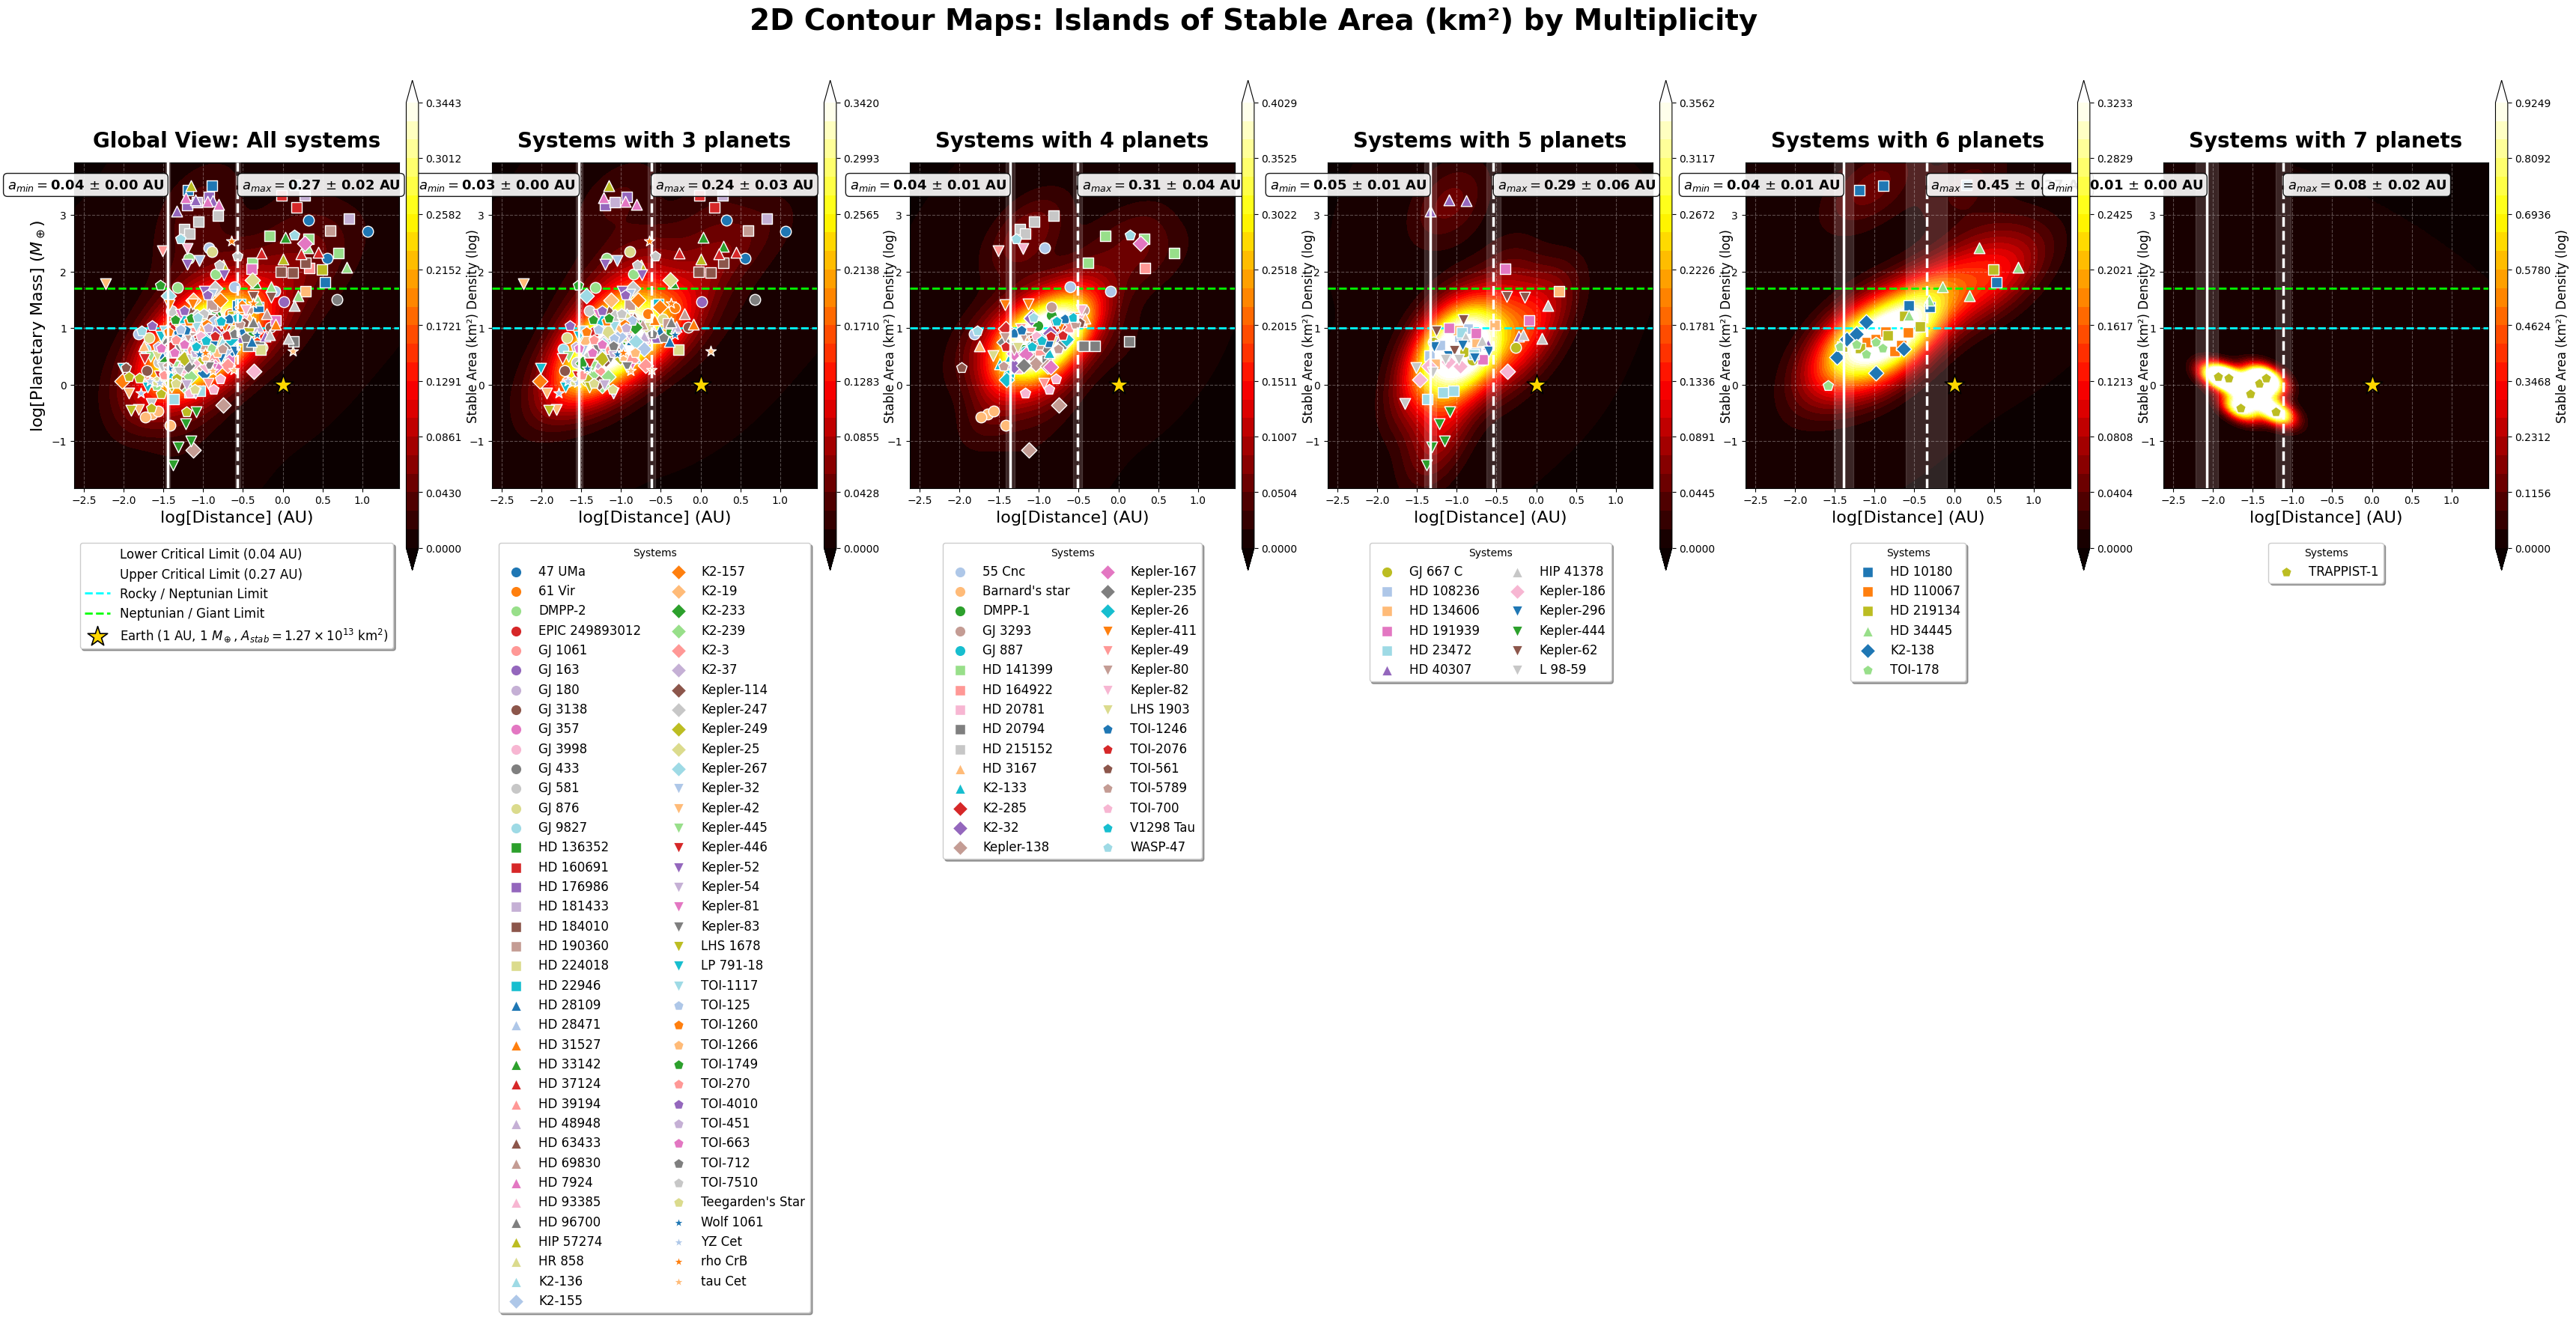


Generating 2D contour map by stellar type for: Area_Estable_km2...


Generando paneles por tipo: 100%|██████████| 4/4 [00:02<00:00,  1.65panel/s]


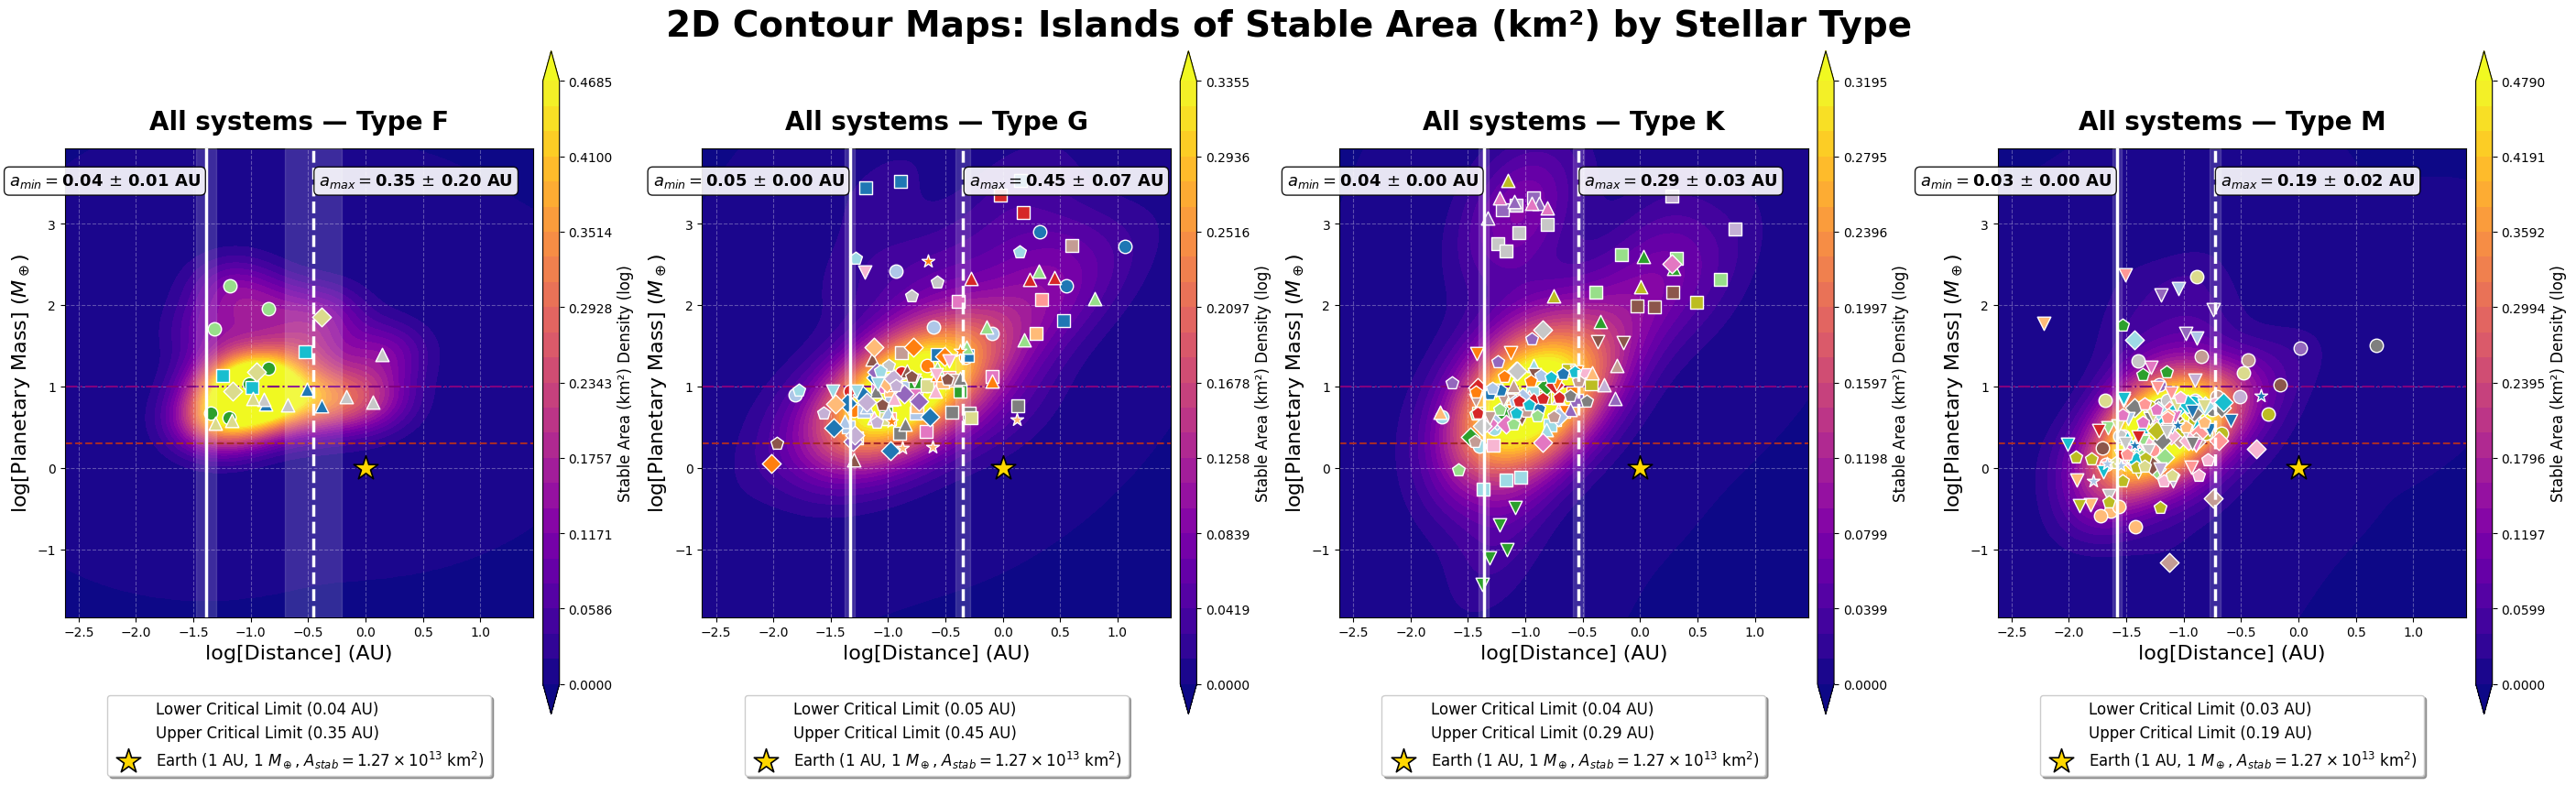


Gráficos generados con éxito.


In [19]:
if __name__ == "__main__":
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)
 
    print("Esperando selección de carpetas en la ventana emergente...")
 
    df_datos, DIRECTORIO_RAIZ = extraer_datos_personalizados()
 
    if not df_datos.empty:
        # --- DIAGNÓSTICO ---
        cantidades_encontradas = sorted(df_datos['Num_Planetas'].unique())
        print(f"\nDiagnóstico: hay sistemas con las siguientes cantidades de planetas: {cantidades_encontradas}")
 
        # ACOTAR: seleccionar solo sistemas con 3 o más planetas
        df_filtrado = df_datos[df_datos['Num_Planetas'] >= 3]
 
        if not df_filtrado.empty:
            print(f"Se graficarán {len(df_filtrado)} planetas que pertenecen a sistemas de 3 o más planetas.")
            plot_islands_zonas_estables2(df_filtrado, DIRECTORIO_RAIZ)
            plot_islands_por_tipo_estrella(df_filtrado, DIRECTORIO_RAIZ)
            print("\nGráficos generados con éxito.")
        else:
            print("\nALERTA: No quedaron datos tras aplicar el filtro de >= 3 planetas.")
    else:
        print("\nNo se encontraron datos válidos, u operación cancelada por el usuario.")

Estrellas G


Esperando selección de carpetas en la ventana emergente...

🔍 Escaneando directorio: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Troyanos/Resultados_Estrellas_G (Tipo G)...
✅ Lectura completada. Se extrajeron datos de 124 planetas.

Diagnóstico: hay sistemas con las siguientes cantidades de planetas: [np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Se graficarán 124 planetas que pertenecen a sistemas de 3 o más planetas.

Generating 2D contour map for: Area_Estable_km2...


Generando paneles: 100%|██████████| 5/5 [00:01<00:00,  3.38panel/s]


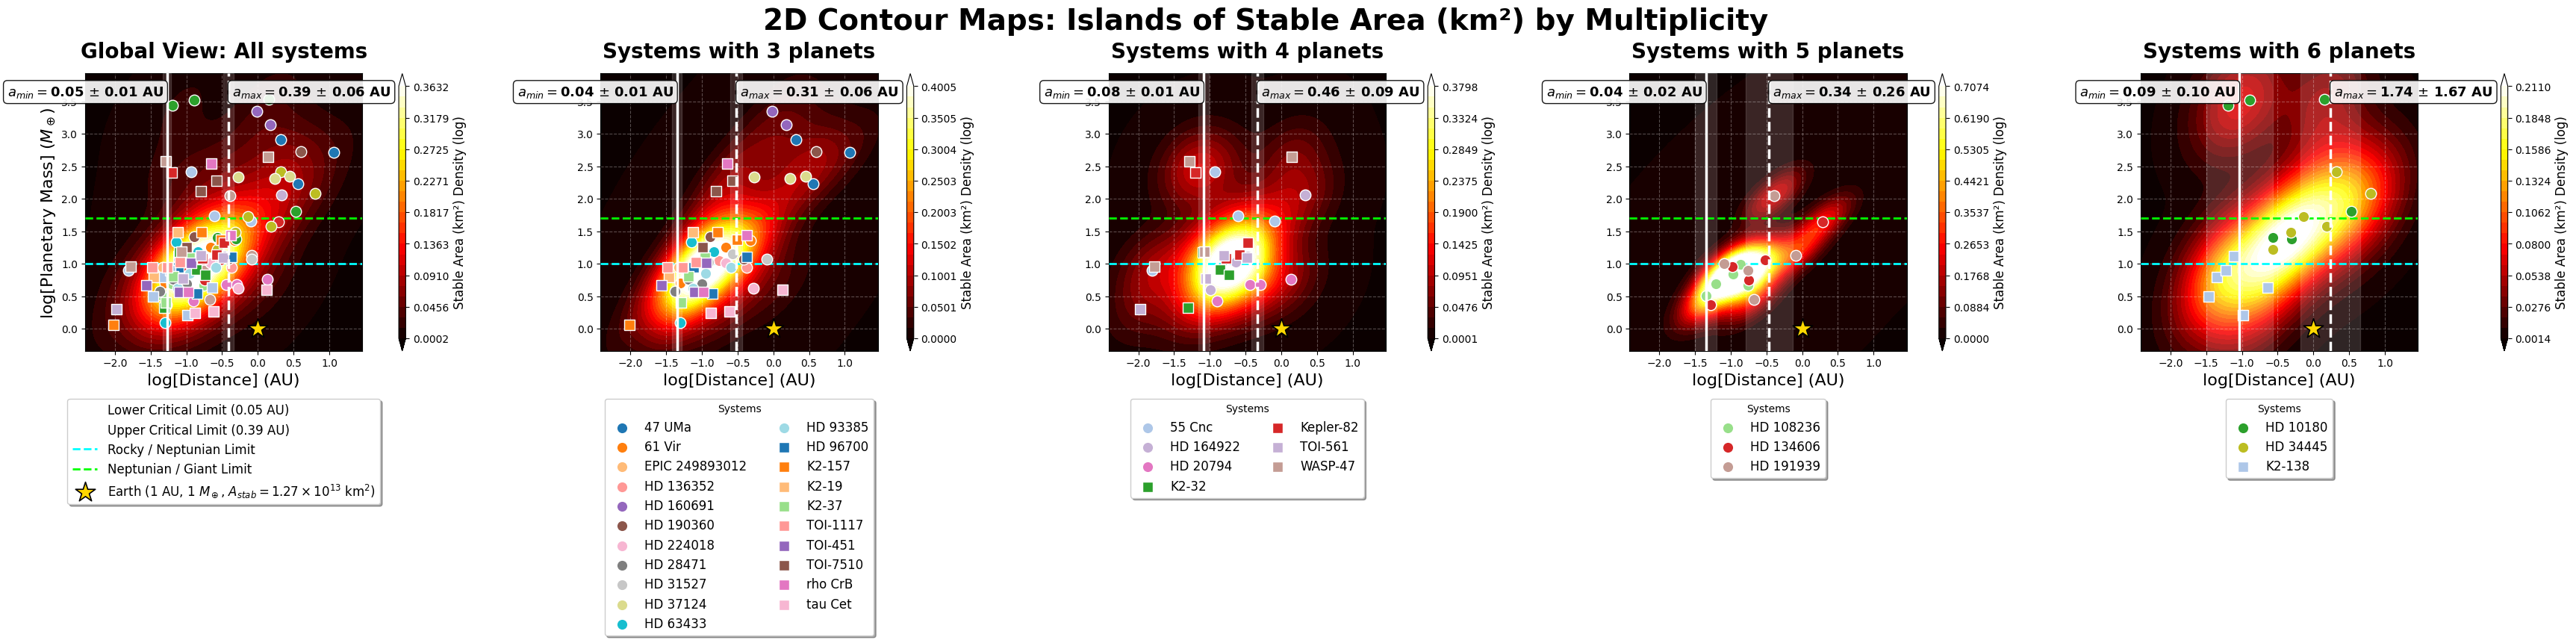


Gráficos generados con éxito.


In [34]:
if __name__ == "__main__":
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)
 
    print("Esperando selección de carpetas en la ventana emergente...")
 
    # FIX: el main llamaba a una función inexistente (extraer_datos_de_carpetas).
    # La función real, interactiva y ya definida en este archivo, es
    # extraer_datos_personalizados() (sin argumentos: pide todo por diálogo).
    df_datos, DIRECTORIO_RAIZ = extraer_datos_personalizados()
 
    if not df_datos.empty:
        # --- DIAGNÓSTICO ---
        cantidades_encontradas = sorted(df_datos['Num_Planetas'].unique())
        print(f"\nDiagnóstico: hay sistemas con las siguientes cantidades de planetas: {cantidades_encontradas}")
 
        # ACOTAR: seleccionar solo sistemas con 3 o más planetas
        df_filtrado = df_datos[df_datos['Num_Planetas'] >= 3]
 
        if not df_filtrado.empty:
            print(f"Se graficarán {len(df_filtrado)} planetas que pertenecen a sistemas de 3 o más planetas.")
            plot_islands_zonas_estables2(df_filtrado, DIRECTORIO_RAIZ)
            print("\nGráficos generados con éxito.")
        else:
            print("\nALERTA: No quedaron datos tras aplicar el filtro de >= 3 planetas.")
    else:
        print("\nNo se encontraron datos válidos, u operación cancelada por el usuario.")

K

Esperando selección de carpetas en la ventana emergente...

🔍 Escaneando directorio: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Troyanos/Resultados_Estrellas_K (Tipo K)...
✅ Lectura completada. Se extrajeron datos de 140 planetas.

Diagnóstico: hay sistemas con las siguientes cantidades de planetas: [np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Se graficarán 140 planetas que pertenecen a sistemas de 3 o más planetas.

Generating 2D contour map for: Area_Estable_km2...


Generando paneles: 100%|██████████| 5/5 [00:01<00:00,  3.05panel/s]


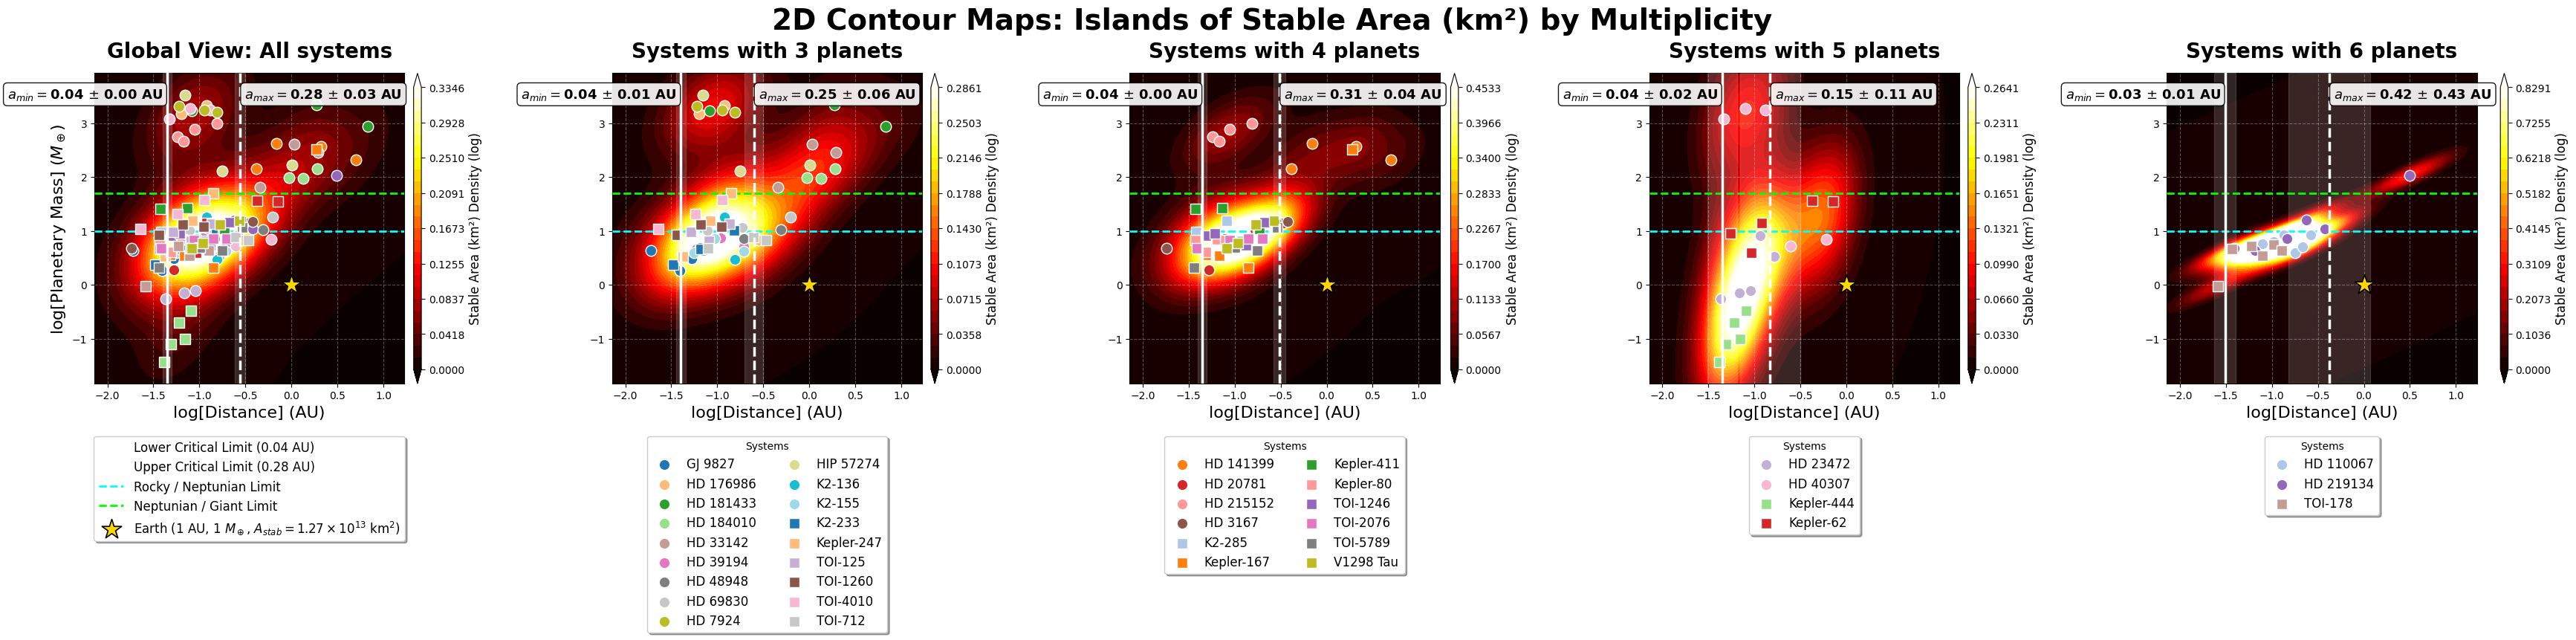


Gráficos generados con éxito.


In [36]:
if __name__ == "__main__":
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)
 
    print("Esperando selección de carpetas en la ventana emergente...")
 
    # FIX: el main llamaba a una función inexistente (extraer_datos_de_carpetas).
    # La función real, interactiva y ya definida en este archivo, es
    # extraer_datos_personalizados() (sin argumentos: pide todo por diálogo).
    df_datos, DIRECTORIO_RAIZ = extraer_datos_personalizados()
 
    if not df_datos.empty:
        # --- DIAGNÓSTICO ---
        cantidades_encontradas = sorted(df_datos['Num_Planetas'].unique())
        print(f"\nDiagnóstico: hay sistemas con las siguientes cantidades de planetas: {cantidades_encontradas}")
 
        # ACOTAR: seleccionar solo sistemas con 3 o más planetas
        df_filtrado = df_datos[df_datos['Num_Planetas'] >= 3]
 
        if not df_filtrado.empty:
            print(f"Se graficarán {len(df_filtrado)} planetas que pertenecen a sistemas de 3 o más planetas.")
            plot_islands_zonas_estables2(df_filtrado, DIRECTORIO_RAIZ)
            print("\nGráficos generados con éxito.")
        else:
            print("\nALERTA: No quedaron datos tras aplicar el filtro de >= 3 planetas.")
    else:
        print("\nNo se encontraron datos válidos, u operación cancelada por el usuario.")

M


Esperando selección de carpetas en la ventana emergente...

🔍 Escaneando directorio: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Troyanos/Resultados_Estrellas_M (Tipo M)...
✅ Lectura completada. Se extrajeron datos de 160 planetas.

Diagnóstico: hay sistemas con las siguientes cantidades de planetas: [np.int64(3), np.int64(4), np.int64(5), np.int64(7)]
Se graficarán 160 planetas que pertenecen a sistemas de 3 o más planetas.

Generating 2D contour map for: Area_Estable_km2...


Generando paneles: 100%|██████████| 5/5 [00:01<00:00,  2.93panel/s]


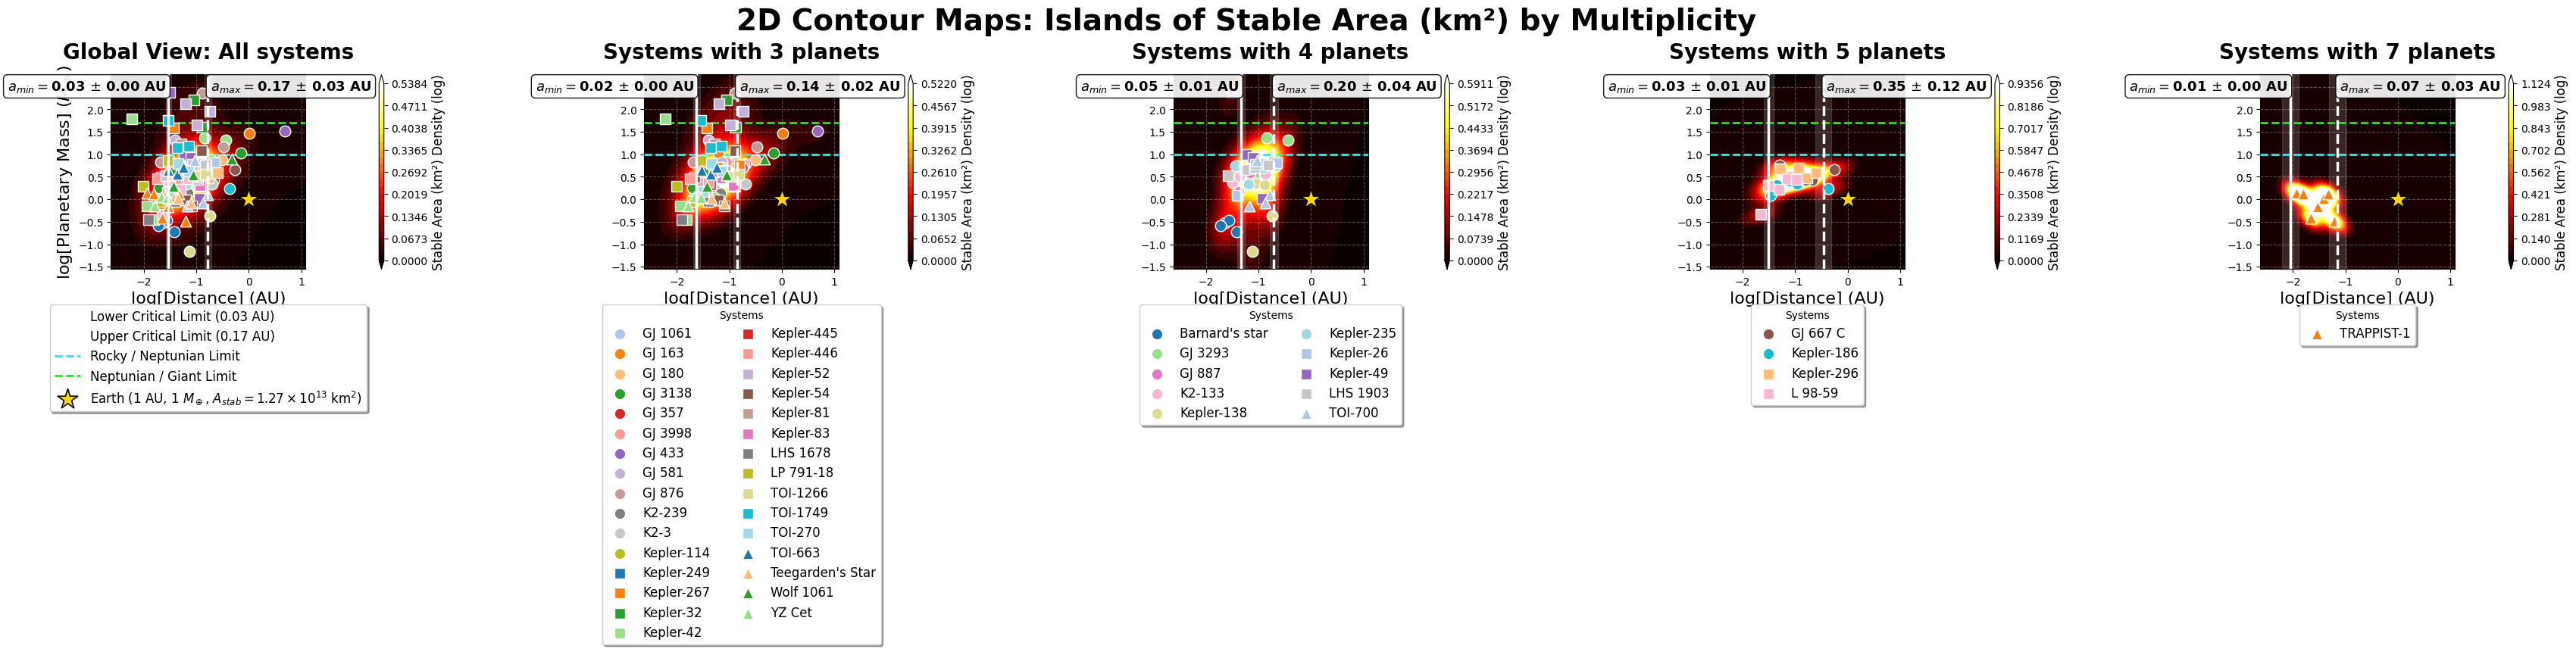


Gráficos generados con éxito.


In [37]:
if __name__ == "__main__":
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)
 
    print("Esperando selección de carpetas en la ventana emergente...")
 
    # FIX: el main llamaba a una función inexistente (extraer_datos_de_carpetas).
    # La función real, interactiva y ya definida en este archivo, es
    # extraer_datos_personalizados() (sin argumentos: pide todo por diálogo).
    df_datos, DIRECTORIO_RAIZ = extraer_datos_personalizados()
 
    if not df_datos.empty:
        # --- DIAGNÓSTICO ---
        cantidades_encontradas = sorted(df_datos['Num_Planetas'].unique())
        print(f"\nDiagnóstico: hay sistemas con las siguientes cantidades de planetas: {cantidades_encontradas}")
 
        # ACOTAR: seleccionar solo sistemas con 3 o más planetas
        df_filtrado = df_datos[df_datos['Num_Planetas'] >= 3]
 
        if not df_filtrado.empty:
            print(f"Se graficarán {len(df_filtrado)} planetas que pertenecen a sistemas de 3 o más planetas.")
            plot_islands_zonas_estables2(df_filtrado, DIRECTORIO_RAIZ)
            print("\nGráficos generados con éxito.")
        else:
            print("\nALERTA: No quedaron datos tras aplicar el filtro de >= 3 planetas.")
    else:
        print("\nNo se encontraron datos válidos, u operación cancelada por el usuario.")

G

Esperando selección de carpeta en la ventana emergente...

🔍 Escaneando directorio: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Resultados_-con_sistemas_2_planetas/Resultados_Estrellas_G...
✅ Lectura completada. Se extrajeron datos válidos de 338 planetas.

Generando mapa de contornos 2D para: Area_Estable_km2...


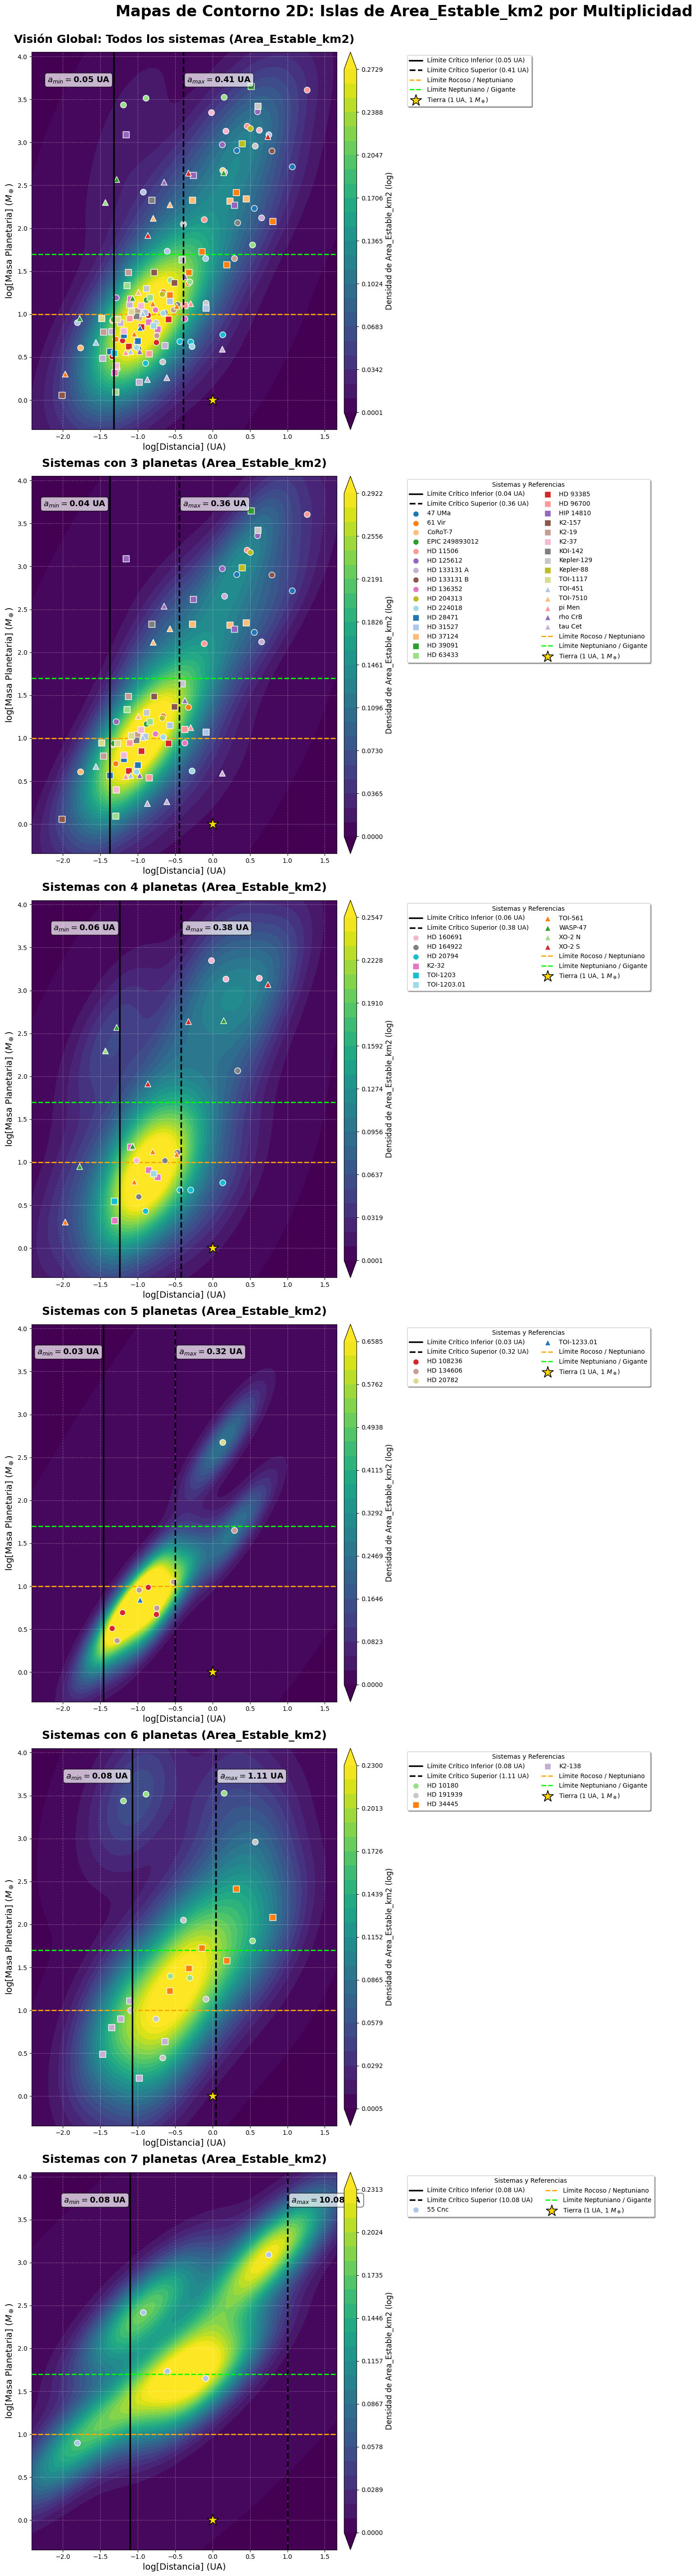

In [10]:
if __name__ == "__main__":
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)

    print("Esperando selección de carpeta en la ventana emergente...")
    DIRECTORIO_RAIZ = filedialog.askdirectory(title="Selecciona la carpeta raíz de resultados")

    if DIRECTORIO_RAIZ:
        # 1. Extraer todos los datos (con arreglo de tildes y m1)
        df_datos = extraer_datos_de_carpetas(DIRECTORIO_RAIZ)
        
        if not df_datos.empty:
            # 2. ACOTAR: Seleccionar solo sistemas con 3 o más planetas
            df_filtrado = df_datos[df_datos['Num_Planetas'] >= 3]
            
            if not df_filtrado.empty:
                plot_islands_zonas_estables2(df_filtrado,DIRECTORIO_RAIZ)
              
            else:
                print("\n⚠️ No quedaron sistemas con 3 o más planetas tras aplicar el filtro.")
        else:
            print("\n❌ No se encontraron datos válidos en la carpeta seleccionada.")
    else:
        print("\n🛑 Operación cancelada por el usuario.")

Esperando selección de carpeta en la ventana emergente...

🔍 Escaneando directorio: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Resultados_-con_sistemas_2_planetas/Resultados_Estrellas_G...
✅ Lectura completada. Se extrajeron datos válidos de 338 planetas.

Generando mapa de contornos 2D para: Area_Estable_km2...


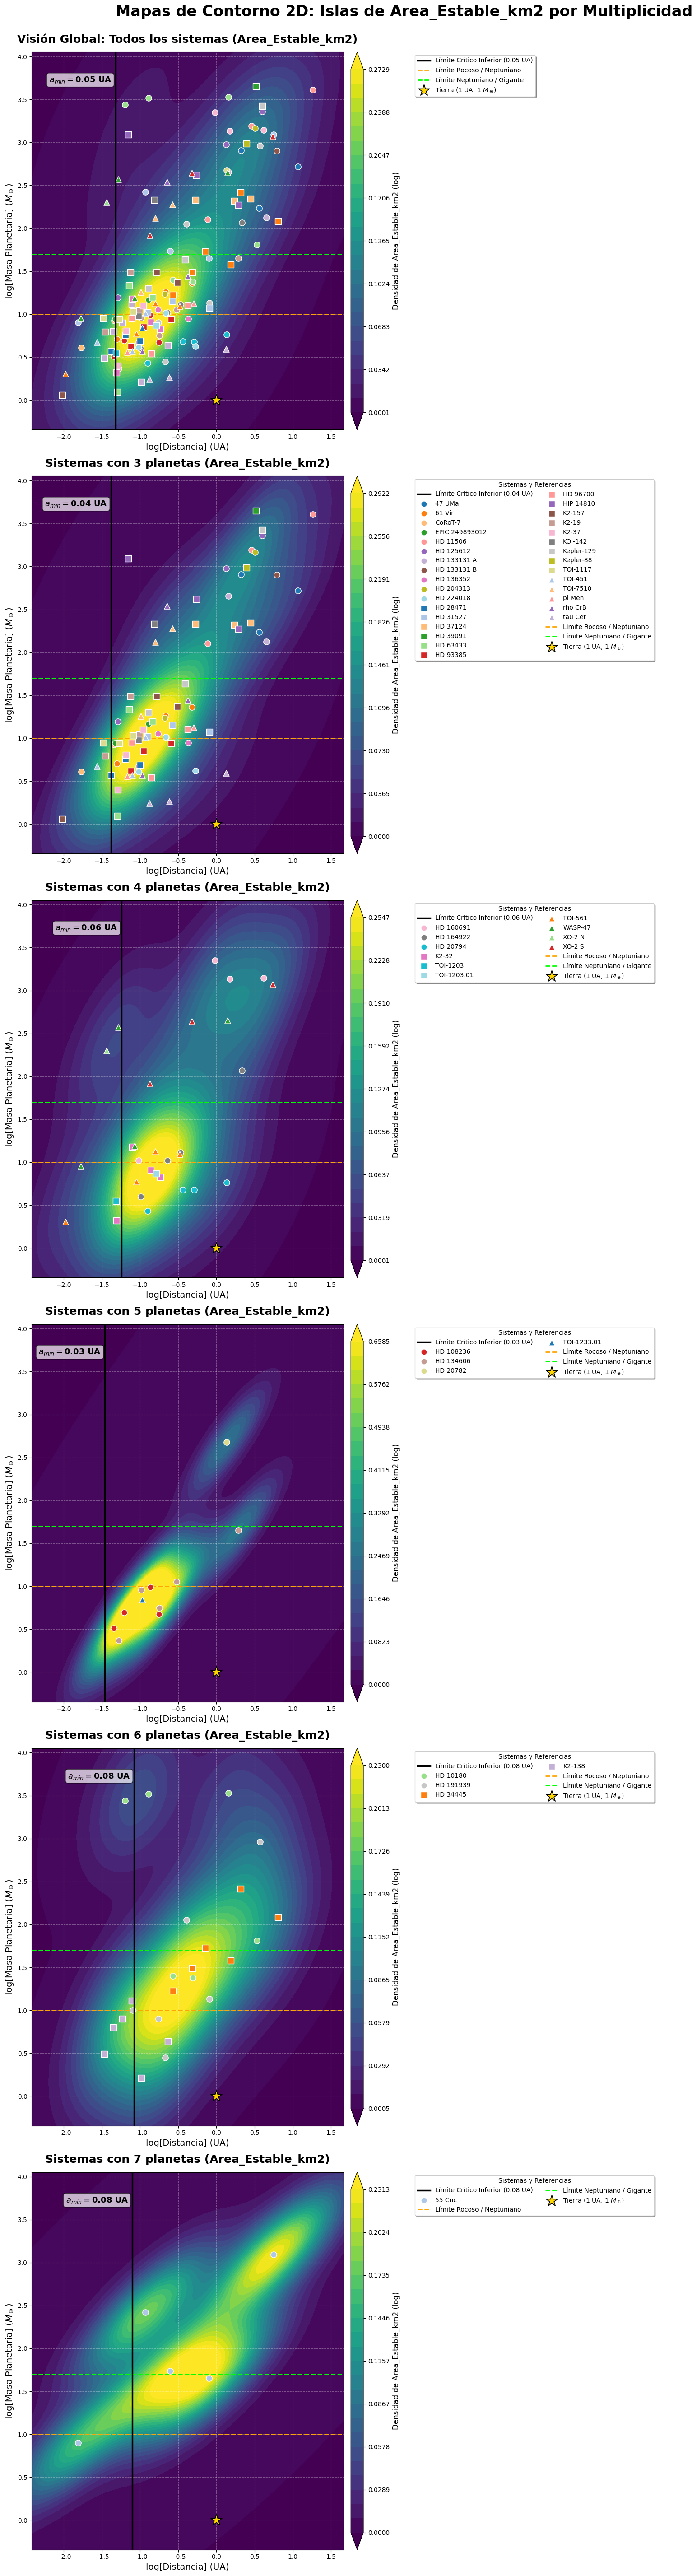

In [58]:
if __name__ == "__main__":
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)

    print("Esperando selección de carpeta en la ventana emergente...")
    DIRECTORIO_RAIZ = filedialog.askdirectory(title="Selecciona la carpeta raíz de resultados")

    if DIRECTORIO_RAIZ:
        # 1. Extraer todos los datos (con arreglo de tildes y m1)
        df_datos = extraer_datos_de_carpetas(DIRECTORIO_RAIZ)
        
        if not df_datos.empty:
            # 2. ACOTAR: Seleccionar solo sistemas con 3 o más planetas
            df_filtrado = df_datos[df_datos['Num_Planetas'] >= 3]
            
            if not df_filtrado.empty:
                plot_islands_zonas_estables(df_filtrado,DIRECTORIO_RAIZ)
              
            else:
                print("\n⚠️ No quedaron sistemas con 3 o más planetas tras aplicar el filtro.")
        else:
            print("\n❌ No se encontraron datos válidos en la carpeta seleccionada.")
    else:
        print("\n🛑 Operación cancelada por el usuario.")

F

Esperando selección de carpeta en la ventana emergente...

🔍 Escaneando directorio: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Resultados_-con_sistemas_2_planetas/Resultados_Estrellas_F...
✅ Lectura completada. Se extrajeron datos válidos de 79 planetas.

Generando mapa de contornos 2D para: Area_Estable_km2...


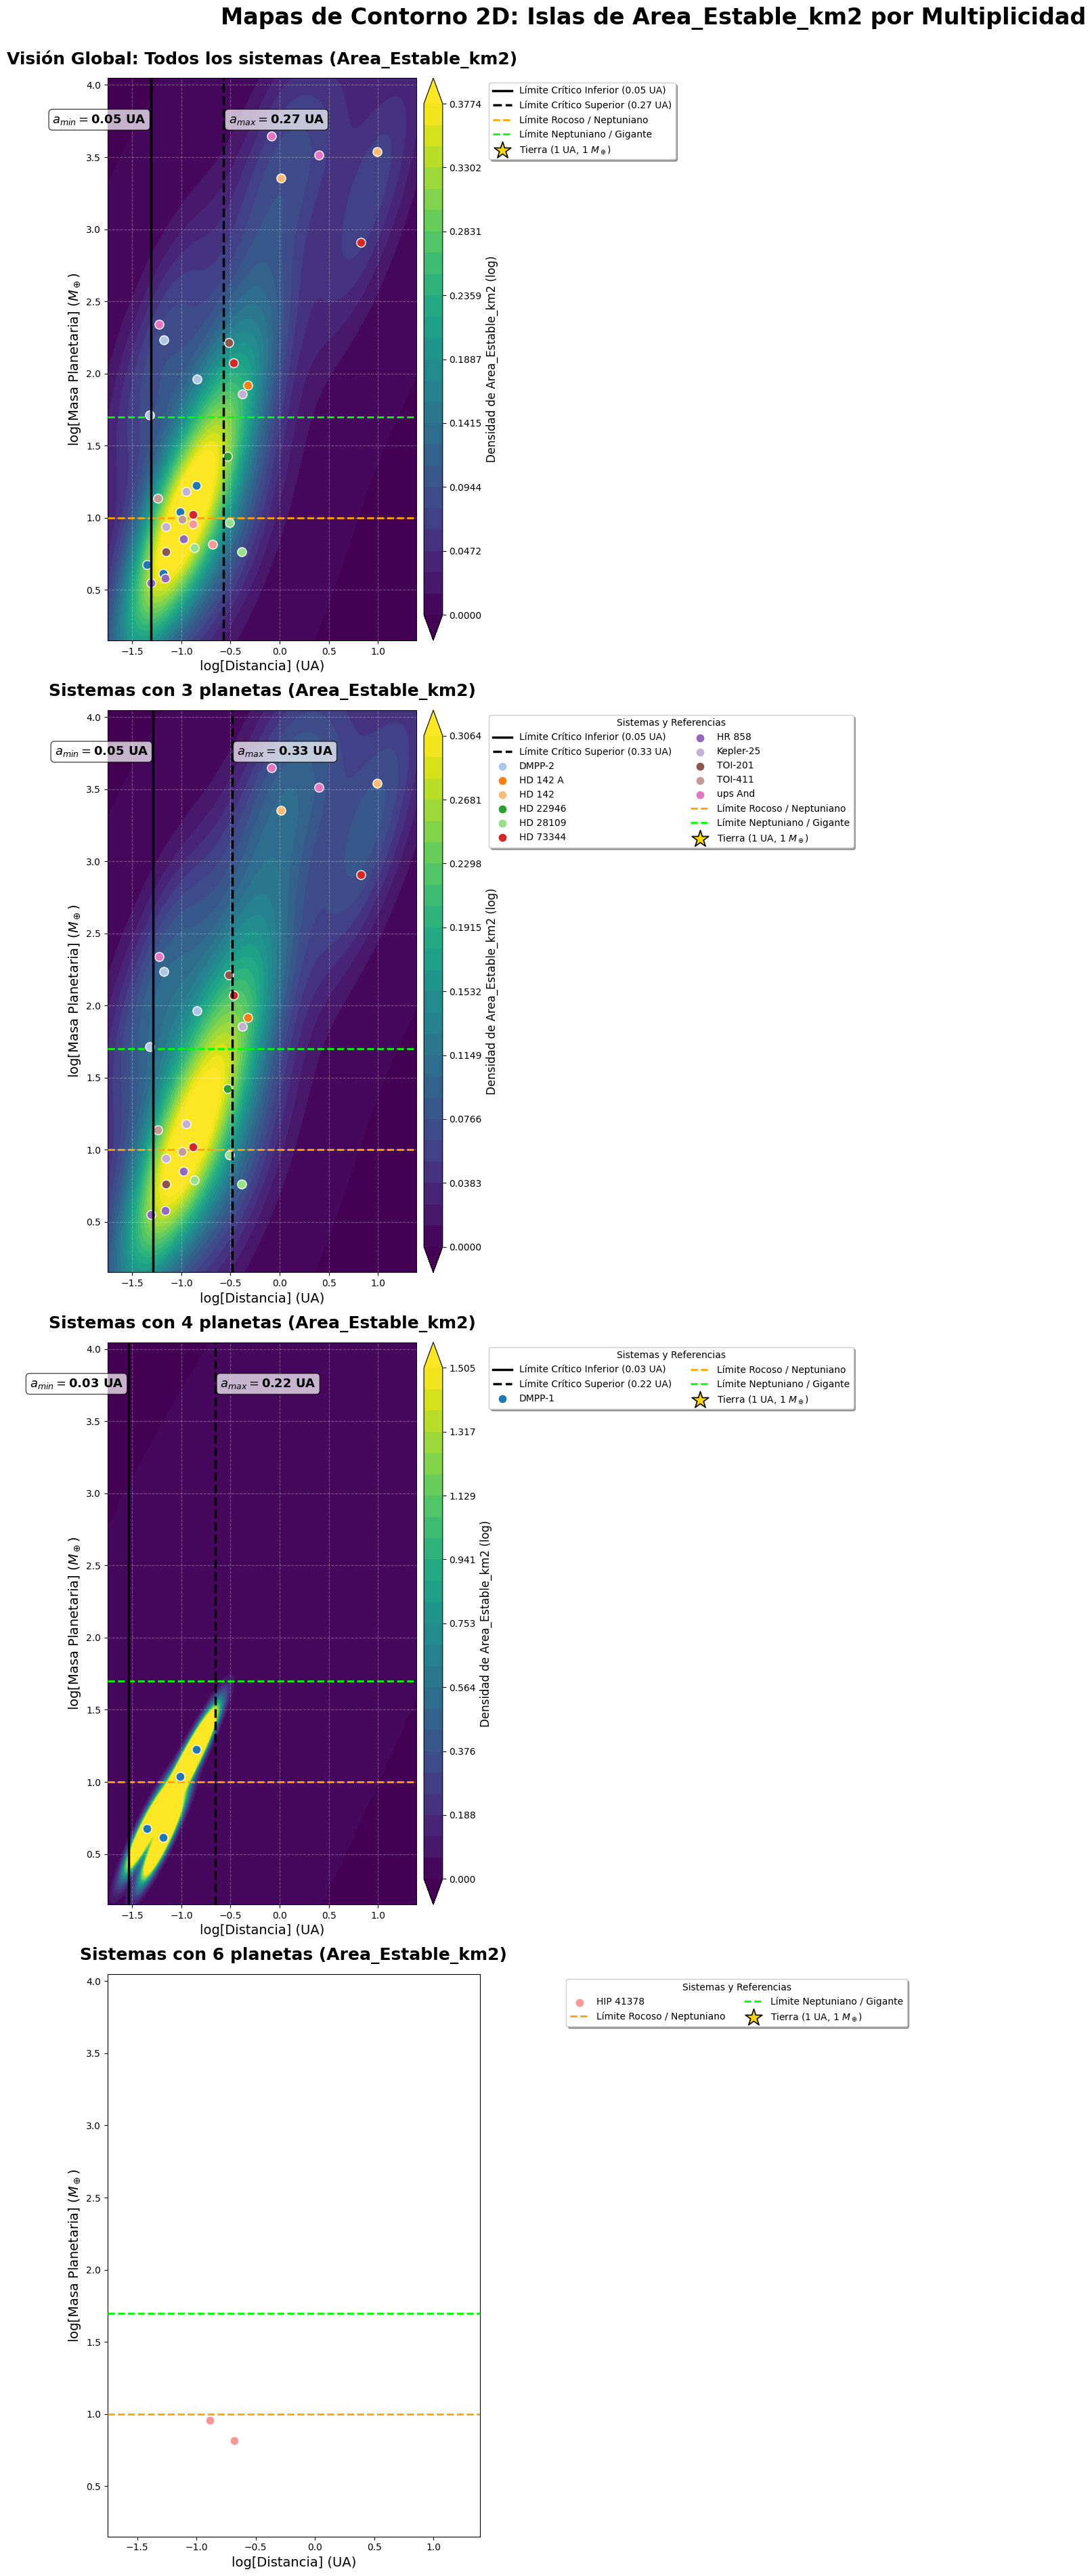

In [11]:
if __name__ == "__main__":
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)

    print("Esperando selección de carpeta en la ventana emergente...")
    DIRECTORIO_RAIZ = filedialog.askdirectory(title="Selecciona la carpeta raíz de resultados")

    if DIRECTORIO_RAIZ:
        # 1. Extraer todos los datos (con arreglo de tildes y m1)
        df_datos = extraer_datos_de_carpetas(DIRECTORIO_RAIZ)
        
        if not df_datos.empty:
            # 2. ACOTAR: Seleccionar solo sistemas con 3 o más planetas
            df_filtrado = df_datos[df_datos['Num_Planetas'] >= 3]
            
            if not df_filtrado.empty:
                plot_islands_zonas_estables2(df_filtrado,DIRECTORIO_RAIZ)
              
            else:
                print("\n⚠️ No quedaron sistemas con 3 o más planetas tras aplicar el filtro.")
        else:
            print("\n❌ No se encontraron datos válidos en la carpeta seleccionada.")
    else:
        print("\n🛑 Operación cancelada por el usuario.")

Esperando selección de carpeta en la ventana emergente...

🔍 Escaneando directorio: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Resultados_-con_sistemas_2_planetas/Resultados_Estrellas_F...
✅ Lectura completada. Se extrajeron datos válidos de 79 planetas.

Generando mapa de contornos 2D para: Area_Estable_km2...


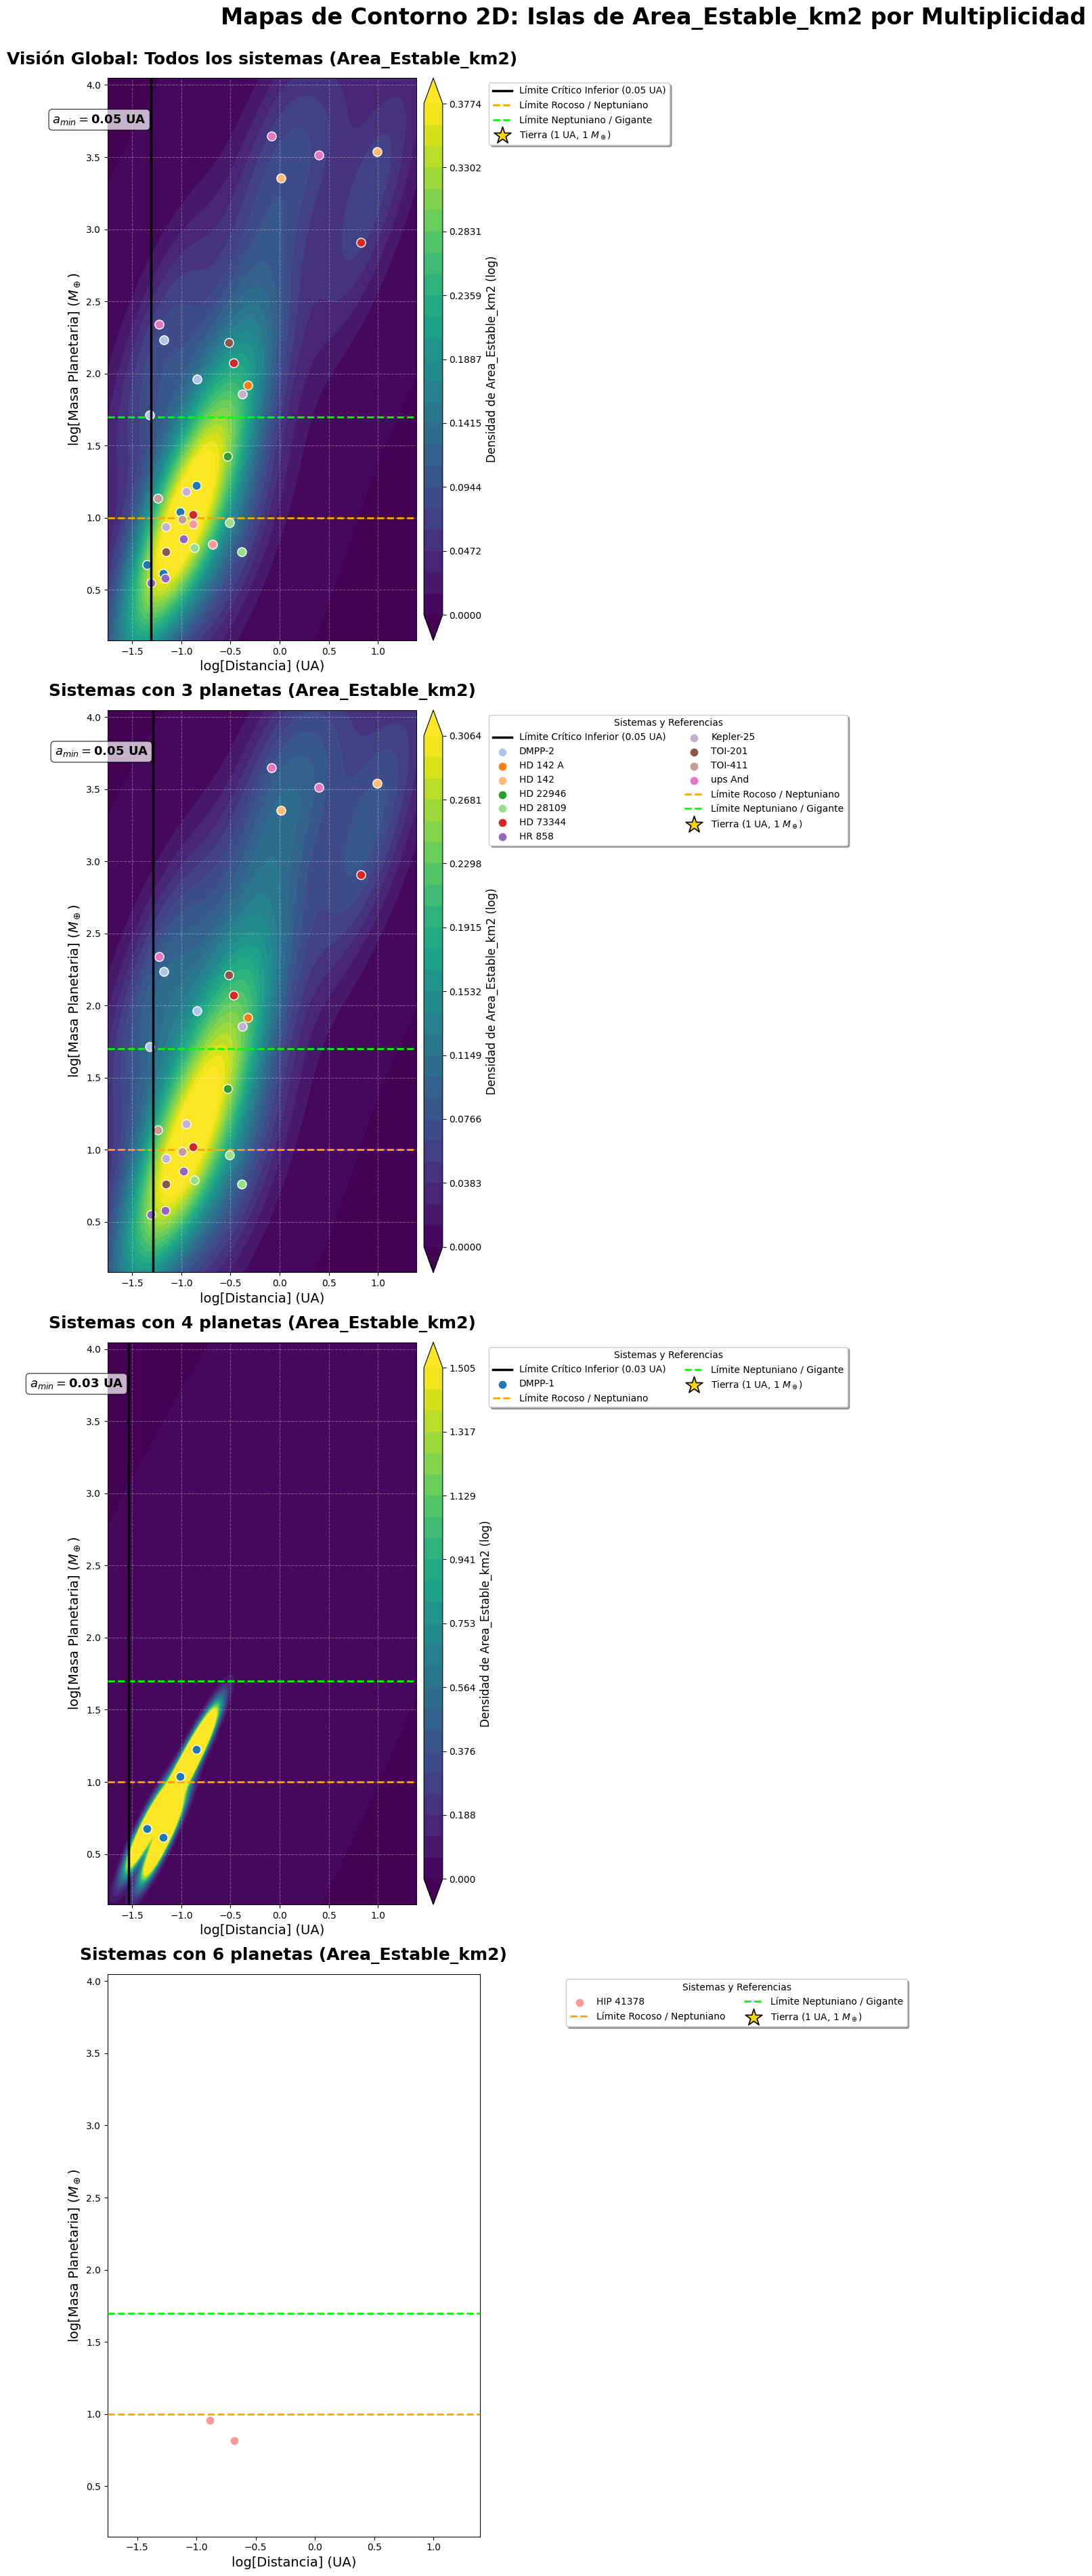

In [61]:
if __name__ == "__main__":
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)

    print("Esperando selección de carpeta en la ventana emergente...")
    DIRECTORIO_RAIZ = filedialog.askdirectory(title="Selecciona la carpeta raíz de resultados")

    if DIRECTORIO_RAIZ:
        # 1. Extraer todos los datos (con arreglo de tildes y m1)
        df_datos = extraer_datos_de_carpetas(DIRECTORIO_RAIZ)
        
        if not df_datos.empty:
            # 2. ACOTAR: Seleccionar solo sistemas con 3 o más planetas
            df_filtrado = df_datos[df_datos['Num_Planetas'] >= 3]
            
            if not df_filtrado.empty:
                plot_islands_zonas_estables(df_filtrado,DIRECTORIO_RAIZ)
              
            else:
                print("\n⚠️ No quedaron sistemas con 3 o más planetas tras aplicar el filtro.")
        else:
            print("\n❌ No se encontraron datos válidos en la carpeta seleccionada.")
    else:
        print("\n🛑 Operación cancelada por el usuario.")